# Урок 09. MLE и MAP

> **Зачем это нужно:** MSE, cross-entropy, L2-регуляризация — это не магия, а MLE/MAP в гауссовой/бернуллиевой постановке.

---

## 1. Функция правдоподобия (Likelihood) и Метод максимального правдоподобия (MLE)

---

## Интуиция и главное отличие: Вероятность vs Правдоподобие

Чтобы не путать эти понятия, достаточно запомнить, что у них разные аргументы (переменные):

*   **Вероятность $P(X|\theta)$:** Параметр $\theta$ (например, средний рост людей или честность монеты) нам **известен**. Мы рассчитываем вероятность получить конкретные новые данные $X$ (например, каков шанс встретить человека ростом выше 190 см).
*   **Правдоподобие $L(\theta|X)$:** Данные $X$ (реальная выборка) уже **собраны и фиксированы**. Мы варьируем параметр модели $\theta$, чтобы понять, при каком именно его значении наша реальная выборка становится наиболее ожидаемой (правдоподобной).

> **Суть:** Вероятность предсказывает данные по известным параметрам. Правдоподобие оценивает параметры по известным данным.

---

## Математическое определение

Пусть у нас есть выборка независимых, одинаково распределенных случайных величин $X = (x_1, x_2, \dots, x_n)$, где каждое наблюдение имеет плотность распределения $f(x_i|\theta)$ (или вероятность $P(x_i|\theta)$ в дискретном случае), зависящую от неизвестного параметра $\theta$.

**Функция правдоподобия $L(\theta|X)$** — это совместная плотность вероятности (или совместная вероятность) всей выборки, рассматриваемая как функция от параметра $\theta$:

$$L(\theta|X) = \prod_{i=1}^{n} f(x_i|\theta)$$

### Логарифмическая функция правдоподобия (Log-Likelihood)
На практике перемножать тысячи маленьких вероятностей неудобно, так как компьютер быстро уходит в машинный ноль (underflow). Кроме того, от произведения сложно брать производные. Поэтому всегда используют логарифм функции правдоподобия. Логарифм — монотонно возрастающая функция, поэтому точка максимума у $L(\theta)$ и $\ln L(\theta)$ совпадает.

Логарифм превращает произведение в сумму:

$$\ln L(\theta|X) = \sum_{i=1}^{n} \ln f(x_i|\theta)$$

---

## 2. Метод максимального правдоподобия (Maximum Likelihood Estimation — MLE)

**MLE** — это метод оценивания неизвестного параметра $\theta$ путем поиска такого значения $\hat{\theta}$, при котором функция правдоподобия (или её логарифм) достигает своего максимума.

$$\hat{\theta}_{MLE} = \arg\max_{\theta} L(\theta|X) = \arg\max_{\theta} \ln L(\theta|X)$$

### Стандартный алгоритм поиска MLE:
1. Записать функцию правдоподобия $L(\theta|X)$.
2. Прологарифмировать её, получив $\ln L(\theta|X)$.
3. Взять производную по оцениваемому параметру: $\frac{\partial}{\partial \theta} \ln L(\theta|X)$.
4. Приравнять производную к нулю (найти критические точки): $\frac{\partial}{\partial \theta} \ln L(\theta|X) = 0$.
5. Убедиться, что это максимум (проверив вторую производную, она должна быть $< 0$).

---

## Классический пример: Подброс монеты (Распределение Бернулли)

1. **Данные ($X$):** Мы подбросили монету $N$ раз. Выпало $K$ орлов (успехов) и $N-K$ решек (неудач).
2. **Модель ($\theta$):** Мы предполагаем, что вероятность выпадения орла равна некоторому $\theta \in [0, 1]$.
3. **Функция правдоподобия:**
   $$L(\theta|X) = \theta^K (1 - \theta)^{N - K}$$
4. **Лог-правдоподобие:**
   $$\ln L(\theta|X) = K \ln(\theta) + (N - K) \ln(1 - \theta)$$
5. **Поиск максимума:**
   Возьмем производную по $\theta$ и приравняем к 0:
   $$\frac{\partial}{\partial \theta} \ln L(\theta|X) = \frac{K}{\theta} - \frac{N - K}{1 - \theta} = 0$$
   $$\frac{K}{\theta} = \frac{N - K}{1 - \theta} \implies K(1 - \theta) = \theta(N - K) \implies K - K\theta = N\theta - K\theta$$
   $$\hat{\theta}_{MLE} = \frac{K}{N}$$

**Вывод:** Оценка максимального правдоподобия для вероятности успеха — это просто доля успехов в выборке (интуитивно понятно и строго доказано).

---

## 3. Свойства оценок максимального правдоподобия

При увеличении объема выборки ($n \to \infty$) оценки, полученные методом MLE, обладают рядом важнейших («асимптотических») свойств:

1. **Состоятельность (Consistency):**
   При росте объема данных оценка $\hat{\theta}_{MLE}$ сходится по вероятности к истинному значению параметра $\theta_0$:
   $$\hat{\theta}_{MLE} \xrightarrow{P} \theta_0 \quad \text{при} \quad n \to \infty$$
   *Простыми словами: чем больше данных, тем точнее оценка приближается к реальности.*

2. **Асимптотическая нормальность (Asymptotic Normality):**
   С ростом выборки распределение самой оценки $\hat{\theta}_{MLE}$ стремится к нормальному распределению с центром в истинном значении $\theta_0$:
   $$\sqrt{n}(\hat{\theta}_{MLE} - \theta_0) \xrightarrow{d} N(0, I^{-1}(\theta_0))$$
   где $I(\theta_0)$ — информация Фишера. Это свойство позволяет легко строить доверительные интервалы для параметров.

3. **Асимптотическая эффективность (Efficiency):**
   Оценка MLE имеет минимально возможную дисперсию среди всех несмещенных оценок при больших выборках. Она достигает так называемой **границы Рао-Крамера**. Это значит, что MLE извлекает из данных максимум возможной информации.

4. **Инвариантность (Invariance):**
   Если $\hat{\theta}_{MLE}$ — это оценка максимального правдоподобия для $\theta$, а $g(\theta)$ — непрерывная функция, то оценка максимального правдоподобия для $g(\theta)$ равна просто $g(\hat{\theta}_{MLE})$.
   *Пример: если оценка для дисперсии $\sigma^2$ равна $\hat{\sigma}^2$, то оценка для стандартного отклонения $\sigma$ будет $\sqrt{\hat{\sigma}^2}$.*

---

## Связь с Машинным Обучением

Метод максимального правдоподобия — это фундамент для большинства алгоритмов обучения:
* **Логистическая регрессия:** Минимизация функции потерь Binary Cross-Entropy (бинарная кросс-энтропия) эквивалентна максимизации логарифма правдоподобия для распределения Бернулли.
* **Линейная регрессия:** Минимизация среднеквадратичной ошибки (MSE) эквивалентна максимизации правдоподобия в предположении, что шум (ошибки) распределен нормально (по Гауссу).


---
---

## Математический вывод функций потерь через MLE: Линейная и Логистическая регрессия

В этом разделе мы подробно разберем, почему в линейной регрессии минимизируют среднеквадратичную ошибку (MSE), а в логистической — кросс-энтропию. Мы докажем, что обе эти функции потерь напрямую следуют из **метода максимального правдоподобия (MLE)** при определенных предположениях о распределении данных.

---

## 4. Линейная регрессия и Среднеквадратичная ошибка (MSE)

В линейной регрессии мы пытаемся предсказать непрерывную целевую переменную $y$ по вектору признаков $x$. 

### Шаг 1: Вероятностное предположение (Гипотеза о шуме)
Мы предполагаем, что реальное значение $y$ связано с линейной комбинацией признаков $w^T x$ следующим образом:
$$y_i = w^T x_i + \epsilon_i$$

Где $\epsilon_i$ — это случайный шум (ошибка измерения), для которого мы делаем ключевое предположение: **шум распределен нормально (по Гауссу)** со средним $0$ и некоторой дисперсией $\sigma^2$:
$$\epsilon_i \sim N(0, \sigma^2)$$

Если шум распределен нормально вокруг нуля, то сама целевая переменная $y_i$ при фиксированном $x_i$ тоже распределена нормально, но со средним, равным предсказанию модели $w^T x_i$:
$$y_i | x_i; w \sim N(w^T x_i, \sigma^2)$$

Она читается так: «Случайная величина $y_{i}$ при условии, что мы знаем $x_{i}$ и параметры $w$, распределена нормально ($\sim N$) со средним значением $w^{T}x_{i}$ и разбросом $\sigma ^{2}$».

---
#### Геометрическая интуиция: Почему $y_i \sim N(w^T x_i, \sigma^2)$?

Если мы зафиксируем конкретный объект $x_i$, то предсказание модели $w^T x_i$ становится обычным фиксированным числом (константой). Единственное случайное, что есть в формуле $y_i = w^T x_i + \epsilon_i$ — это шум $\epsilon_i$.

Поскольку шум распределен нормально вокруг нуля ($\epsilon_i \sim N(0, \sigma^2)$), то прибавление к нему константы $w^T x_i$ просто сдвигает центр этого нормального распределения («колокола») из нуля в точку предсказания:

*   **Математически:** Если к случайной величине со средним $0$ прибавить константу $C$, её новое среднее станет равным $C$, а разброс (дисперсия) не изменится.
---

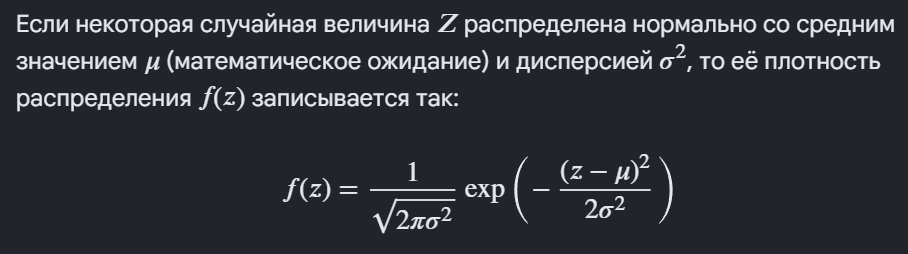
Плотность распределения для одного наблюдения $y_i$ записывается как:
$$f(y_i | x_i; w) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - w^T x_i)^2}{2\sigma^2} \right)$$

### Шаг 2: Функция правдоподобия
Предполагая, что все наблюдения в выборке независимы, функция правдоподобия для вектора весов $w$ равна произведению плотностей:
$$L(w) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - w^T x_i)^2}{2\sigma^2} \right)$$

### Шаг 3: Логарифмирование (Log-Likelihood)
Применим натуральный логарифм, чтобы превратить произведение в сумму:
$$\ln L(w) = \sum_{i=1}^{n} \ln \left( \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(y_i - w^T x_i)^2}{2\sigma^2} \right) \right)$$
$$\ln L(w) = \sum_{i=1}^{n} \left[ \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right) - \frac{(y_i - w^T x_i)^2}{2\sigma^2} \right]$$
$$\ln L(w) = n \cdot \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - w^T x_i)^2$$

### Шаг 4: Максимизация правдоподобия $\to$ Минимизация MSE
Мы хотим найти такие веса $w$, которые максимизируют $\ln L(w)$. 
Обратите внимание на слагаемые:
1. Первая часть $n \cdot \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)$ никак не зависит от весов $w$, это константа.
2. Во второй части перед суммой стоит знак **минус**.

Чтобы **максимизировать** выражение со знаком минус, нам нужно **минимизировать** саму сумму. Константы $\frac{1}{2\sigma^2}$ на точку минимума не влияют. Получаем:
$$\arg\max_{w} \ln L(w) = \arg\min_{w} \sum_{i=1}^{n} (y_i - w^T x_i)^2$$

Если мы разделим эту сумму на количество элементов $n$, мы получим в точности формулу среднеквадратичной ошибки (**Mean Squared Error**):
$$MSE(w) = \frac{1}{n} \sum_{i=1}^{n} (y_i - w^T x_i)^2$$

> **Вывод:** Минимизация MSE в линейной регрессии — это прямое следствие максимизации правдоподобия в условиях, когда случайные ошибки распределены по Гауссу.

---

## 5. Логистическая регрессия и Бинарная кросс-энтропия (Log-Loss)

В задачах бинарной классификации целевая переменная $y_i \in \{0, 1\}$. Линейная функция $w^T x$ может принимать любые значения от $-\infty$ до $+\infty$, поэтому её пропускают через сигмоиду $\sigma(z) = \frac{1}{1 + e^{-z}}$, чтобы получить вероятность.

### Шаг 1: Вероятностное предположение
Модель предсказывает вероятность того, что объект принадлежит к классу 1:
$$P(y_i = 1 | x_i; w) = h_w(x_i) = \frac{1}{1 + e^{-w^T x_i}}$$
Соответственно, вероятность встретить класс 0 равна:
$$P(y_i = 0 | x_i; w) = 1 - h_w(x_i)$$

Такое распределение (где возможны только два исхода с фиксированной вероятностью) называется **распределением Бернулли**. Мы можем объединить обе строчки в одну красивую математическую формулу вероятности для единичного наблюдения:
$$P(y_i | x_i; w) = [h_w(x_i)]^{y_i} \cdot [1 - h_w(x_i)]^{1 - y_i}$$

*Проверка:*
* Если $y_i = 1$, то $[1 - h_w(x_i)]^0 = 1$, остается только $[h_w(x_i)]^1$. Формула верна.
* Если $y_i = 0$, то $[h_w(x_i)]^0 = 1$, остается только $[1 - h_w(x_i)]^1$. Формула верна.

### Шаг 2: Функция правдоподобия
Для всей выборки независимых объектов функция правдоподобия имеет вид произведения вероятностей Бернулли:
$$L(w) = \prod_{i=1}^{n} [h_w(x_i)]^{y_i} \cdot [1 - h_w(x_i)]^{1 - y_i}$$

### Шаг 3: Логарифмирование (Log-Likelihood)
Берем натуральный логарифм. Согласно свойствам логарифма ($\ln(a \cdot b) = \ln a + \ln b$ и $\ln(a^b) = b \ln a$), произведение превращается в сумму, а степени выносятся вперед:
$$\ln L(w) = \sum_{i=1}^{n} \left[ y_i \ln h_w(x_i) + (1 - y_i) \ln(1 - h_w(x_i)) \right]$$

### Шаг 4: Переход к минимизации функции потерь
В машинном обучении традиционно принято функции потерь **минимизировать** (задача Gradient Descent), а не максимизировать. Чтобы превратить задачу поиска максимума правдоподобия в задачу поиска минимума потерь, мы просто умножаем выражение на $-1$ (и делим на $n$ для усреднения по выборке).

Получаем функцию потерь **Binary Cross-Entropy (BCE)**, она же **Log-Loss**:
$$J(w) = - \frac{1}{n} \sum_{i=1}^{n} \left[ y_i \ln h_w(x_i) + (1 - y_i) \ln(1 - h_w(x_i)) \right]$$

> **Вывод:** Функция потерь бинарной кросс-энтропии — это не случайная эвристика, а строго отрицательное логарифмическое правдоподобие (Negative Log-Likelihood) для данных, подчиняющихся распределению Бернулли.


---

## 6. Метод максимальной апостериорной вероятности (Maximum A Posteriori — MAP)

---

## Зачем нужен MAP, если есть MLE?

Метод максимального правдоподобия (MLE) ищет параметры $\theta$, опираясь **исключительно на собранные данные** $X$:
$$\hat{\theta}_{MLE} = \arg\max_{\theta} P(X|\theta)$$

Но у MLE есть огромный минус — **чувствительность к малым выборкам и шуму**. 
*   *Пример:* Вы подбросили монету 3 раза, и все 3 раза выпал орёл. Метод MLE выдаст оценку $\hat{\theta}_{MLE} = 1.0$. Модель заявит, что решка не выпадет *никогда в жизни*. 
*   Ваш здравый смысл (жизненный опыт) говорит: «Монеты обычно честные, вероятность должна быть около $0.5$». 

**Метод MAP** позволяет математически объединить наш прошлый опыт (априорное знание) и новые собранные данные.

---

## Математический вывод через теорему Байеса

Чтобы найти наиболее вероятный параметр $\theta$ при условии, что мы уже увидели данные $X$, нам нужно максимизировать **апостериорную вероятность** $P(\theta|X)$. Воспользуемся теоремой Байеса:

$$P(\theta|X) = \frac{P(X|\theta) \cdot P(\theta)}{P(X)}$$

Где:
*   $P(\theta|X)$ — **Апостериорная вероятность** (Posterior). Вероятность параметров после анализа данных. Её мы и хотим максимизировать.
*   $P(X|\theta)$ — **Правдоподобие** (Likelihood). То, что максимизирует метод MLE (насколько данные объясняются параметрами).
*   $P(\theta)$ — **Априорная вероятность** (Prior). Наши убеждения о параметрах $\theta$ *до* того, как мы увидели данные.
*   $P(X)$ — **Полная вероятность данных** (Evidence). Нам не нужно её считать, так как это просто константа-нормализатор, которая не зависит от $\theta$ и не влияет на точку максимума.

Поскольку $P(X)$ не влияет на оптимизацию, мы можем отбросить знаменатель:
$$\hat{\theta}_{MAP} = \arg\max_{\theta} P(\theta|X) = \arg\max_{\theta} [P(X|\theta) \cdot P(\theta)]$$

### Переход к логарифмам (Log-MAP)
Как и в случае с MLE, произведение неудобно оптимизировать. Мы берем натуральный логарифм, который превращает умножение в сумму:

$$\hat{\theta}_{MAP} = \arg\max_{\theta} \left[ \ln P(X|\theta) + \ln P(\theta) \right]$$

> **Суть MAP:** Формула состоит из двух частей. Первая часть ($\ln P(X|\theta)$) — это знакомое нам MLE, которое заставляет модель подстраиваться под данные. Вторая часть ($\ln P(\theta)$) — это штраф, который «подтягивает» параметры к нашим априорным ожиданиям, не давая им слишком сильно отклоняться.

---

## Живой пример: Возвращаемся к монете

Пусть мы подбросили монету $N=3$ раза и получили $K=3$ орла. 
Мы вводим априорное знание: мы считаем, что монета скорее всего честная. Математически это можно выразить через Бета-распределение параметров, но для простоты представим, что функция $\ln P(\theta)$ штрафует модель тем сильнее, чем дальше $\theta$ уходит от значения $0.5$.

*   Если модель выберет $\theta = 1.0$ (как в MLE): правдоподобие будет высоким, но априорный штраф $\ln P(1.0)$ окажется огромным (так как монета не может быть абсолютно скошенной). Сумма уменьшится.
*   Если модель выберет $\theta = 0.6$: правдоподобие данных чуть упадет, зато априорная вероятность будет очень высокой. Сумма окажется максимальной.

**Итог:** MAP найдет компромисс (например, $\hat{\theta}_{MAP} = 0.62$), сбалансировав крошечную выборку и здравый смысл. При росте объема данных ($N \to \infty$) влияние априорного знания угасает, и оценка MAP плавно сходится к MLE.

---

## Фундаментальная связь MAP с регуляризацией (L1 / L2)

В машинном обучении для борьбы с переобучением к функции потерь прибавляют регуляризаторы (L1 или L2). Оказывается, **регуляризация — это и есть MAP**, где мы накладываем определенное распределение на веса модели $w$.

Рассмотрим линейную регрессию, где мы максимизируем логарифм правдоподобия (что эквивалентно минимизации MSE, как мы доказали ранее):

$$\ln P(X|w) = -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - w^T x_i)^2 + \text{const}$$

### А) Как из MAP получается L2-регуляризация (Ridge / Гребневая регрессия)
Предположим, что мы заранее верим, что веса модели $w$ должны быть небольшими и распределены **нормально (по Гауссу)** вокруг нуля с дисперсией $\tau^2$: $w \sim N(0, \tau^2)$.
Тогда априорная плотность для весов (для одного веса) равна:
$$P(w_j) = \frac{1}{\sqrt{2\pi\tau^2}} \exp\left(-\frac{w_j^2}{2\tau^2}\right)$$
Логарифм априорной вероятности для всего вектора весов (сумма логарифмов):
$$\ln P(w) = \sum_{j} \ln P(w_j) = -\frac{1}{2\tau^2} \sum_{j} w_j^2 + \text{const}$$

Подставим правдоподобие и априорное знание в формулу MAP:
$$\arg\max_{w} \left[ -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - w^T x_i)^2 - \frac{1}{2\tau^2} \sum_{j} w_j^2 \right]$$

Умножим всё выражение на $-1$ (чтобы перейти к минимизации) и на константу $\sigma^2$:
$$\arg\min_{w} \left[ \frac{1}{2} \sum_{i=1}^{n} (y_i - w^T x_i)^2 + \frac{\sigma^2}{2\tau^2} \sum_{j} w_j^2 \right]$$

Обозначим константу $\frac{\sigma^2}{\tau^2}$ как гиперпараметр $\lambda$. Мы получили чистую **L2-регуляризацию**:
$$Loss = \frac{1}{2} MSE + \frac{\lambda}{2} \sum_{j} w_j^2$$

### Б) Как из MAP получается L1-регуляризация (Lasso / Лассо регрессия)
Если вместо нормального распределения мы предположим, что веса $w$ распределены по **закону Лапласа (двойное экспоненциальное)** вокруг нуля: $P(w_j) = \frac{1}{2b} \exp\left(-\frac{|w_j|}{b}\right)$.

Взяв логарифм, мы получим модуль весов:
$$\ln P(w) = -\frac{1}{b} \sum_{j} |w_j| + \text{const}$$

Повторив те же шаги подстановки в MAP, мы придем к минимизации функции потерь с **L1-регуляризатором**:
$$Loss = \frac{1}{2} MSE + \lambda \sum_{j} |w_j|$$

---

## Итоговое сравнение подходов в статистике

| Критерий | MLE (Maximum Likelihood) | MAP (Maximum A Posteriori) | Байесовский подход (Full Bayesian) |
| :--- | :--- | :--- | :--- |
| **Что максимизируем?** | Правдоподобие $P(X\|\theta)$ | Апостериорную плотность $P(\theta\|X)$ | Ничего не максимизируем |
| **Учитываем априорные знания?** | Нет | Да (через $P(\theta)$) | Да (через $P(\theta)$) |
| **Что получаем на выходе?** | Одно точечное значение $\hat{\theta}$ | Одно точечное значение $\hat{\theta}$ | **Распределение** вероятностей всех возможных $\theta$ |
| **Связь с ML** | Стандартные функции потерь (MSE, BCE) | Функции потерь + Регуляризация (L1, L2) | Байесовские нейросети (редко из-за сложности расчетов) |


---
---
# L1-регуляризация (Lasso) и Закон Лапласа

---

## 1. Что такое Закон Лапласа (Распределение Лапласа)?

**Распределение Лапласа** (также известное как *двойное экспоненциальное распределение*) — это непрерывное распределение вероятностей. Его можно представить как два экспоненциальных распределения, соединенных «спина к спине» в точке симметрии.

### Плотность распределения Лапласа
Если случайная величина $w$ (в нашем случае — вес модели) распределена по Лапласу вокруг нуля ($w \sim \text{Laplace}(0, b)$), то её плотность вероятности задается формулой:

$$f(w) = \frac{1}{2b} \exp\left( -\frac{|w|}{b} \right)$$

Где:
*   $|w|$ — модуль (абсолютное значение) веса. Именно он обеспечивает симметрию распределения относительно нуля.
*   $b > 0$ — параметр масштаба (scale). Чем меньше $b$, тем более острым и узким становится пик распределения, и тем сильнее значения прижимаются к нулю.

### Ключевое отличие от распределения Гаусса (нормального)
*   **Гаусс ($N(0, \sigma^2)$):** Имеет гладкую, закругленную вершину в нуле. Плотность убывает пропорционально *квадрату* расстояния ($\propto e^{-w^2}$).
*   **Лаплас ($\text{Laplace}(0, b)$):** Имеет **острый пик (недифференцируемый излом)** ровно в точке $w = 0$. Плотность падает пропорционально *модулю* расстояния ($\propto e^{-|w|}$). 

> **Интуиция:** Пик в нуле у Лапласа выражен гораздо сильнее, чем у Гаусса. Это означает наше жесткое априорное убеждение: *"Большинство весов модели должны быть строго равны нулю, а выживут только самые важные"*.

---

## 2. Математический вывод L1-регуляризации из MAP

Давайте докажем это строго. Мы используем метод максимизации апостериорной вероятности (MAP) для линейной регрессии:

$$\hat{w}_{MAP} = \arg\max_{w} \left[ \ln P(X|w) + \ln P(w) \right]$$

### Шаг 1: Логарифм правдоподобия ($\ln P(X|w)$)
Как мы доказывали ранее, для выборки с гауссовским шумом логарифм правдоподобия имеет вид:
$$\ln P(X|w) = -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - w^T x_i)^2 + \text{const}_1$$

### Шаг 2: Логарифм априорной вероятности Лапласа ($\ln P(w)$)
Предположим, что каждый вес $w_j$ нашей модели независим и распределен по закону Лапласа со средним $0$ и масштабом $b$. Тогда общая априорная плотность для всего вектора весов — это произведение индивидуальных плотностей:
$$P(w) = \prod_{j=1}^{m} \frac{1}{2b} \exp\left( -\frac{|w_j|}{b} \right)$$

Возьмем натуральный логарифм. Логарифм произведения превращается в сумму:
$$\ln P(w) = \sum_{j=1}^{m} \ln \left( \frac{1}{2b} \exp\left( -\frac{|w_j|}{b} \right) \right)$$
$$\ln P(w) = \sum_{j=1}^{m} \left[ \ln\left(\frac{1}{2b}\right) - \frac{|w_j|}{b} \right] = \underbrace{m \cdot \ln\left(\frac{1}{2b}\right)}_{\text{const}_2} - \frac{1}{b} \sum_{j=1}^{m} |w_j|$$

### Шаг 3: Объединение в формулу MAP
Подставим оба слагаемых в оптимизационную задачу:
$$\arg\max_{w} \left[ -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - w^T x_i)^2 - \frac{1}{b} \sum_{j=1}^{m} |w_j| \right]$$

Умножим всё выражение на $-1$ (чтобы инвертировать задачу из максимизации в **минимизацию**) и для удобства умножим на $\sigma^2$:
$$\arg\min_{w} \left[ \frac{1}{2} \sum_{i=1}^{n} (y_i - w^T x_i)^2 + \frac{\sigma^2}{b} \sum_{j=1}^{m} |w_j| \right]$$

Обозначим константу $\frac{\sigma^2}{b}$ как гиперпараметр регуляризации $\lambda$. Мы получили каноническую функцию потерь **L1-регуляризации (Lasso регрессия)**:
$$Loss_{L1} = \frac{1}{2} MSE + \lambda \sum_{j=1}^{m} |w_j|$$

---

## 3. Почему L1 зануляет веса (Feature Selection), а L2 нет?

Существует два объяснения этого феномена: геометрическое и аналитическое.

### А) Геометрическое объяснение (Ограничения)
Задачу минимизации функции потерь с регуляризацией можно переписать как задачу оптимизации при ограничении (бюджете на веса):
*   **L2-регуляризация (Ridge):** $\sum w_j^2 \le C$ — область допустимых весов представляет собой **круг (сферу)**.
*   **L1-регуляризация (Lasso):** $\sum |w_j| \le C$ — область допустимых весов представляет собой **ромб (многогранник с острыми углами)**.

Линии уровня функции потерь (ошибки MSE) представляют собой эллипсы, которые расширяются из центра оптимального решения. 
*   В случае **L2 (круга)** расширяющийся эллипс ошибки с огромной вероятностью коснется круга где-то на его округлой стороне. В этой точке оба веса будут малы, но *не равны нулю*.
*   В случае **L1 (ромба)** расширяющийся эллипс с высокой вероятностью впервые коснется ромба ровно в одном из его **острых углов**. А вершины ромба лежат строго на осях координат! В вершине ромба одна из координат (один из весов признака) **строго равна нулю**.

### Б) Аналитическое объяснение (Производная)
Посмотрим, как веса обновляются при градиентном спуске:
*   Для **L2** штраф равен $\lambda w^2$, его производная $2\lambda w$. Штраф пропорционален размеру веса. Если вес уже очень маленький (например, $w = 0.001$), то градиент штрафа ничтожно мал ($0.002\lambda$). Модель теряет стимул уменьшать его дальше, и вес бесконечно долго стремится к нулю, но никогда его не достигает.
*   Для **L1** штраф равен $\lambda |w|$, его производная равна $\lambda \cdot \text{sign}(w)$ (константа $+1$ или $-1$). Независимо от того, равен ли вес $w=100$ или $w=0.001$, штраф толкает его к нулю **с одинаковой постоянной силой** $\lambda$. Поэтому L1-регуляризатор легко преодолевает последние микро-значения веса и принудительно зануляет его.

---

## 4. Резюме

*   **L1 (Лассо)** штрафует за сумму модулей весов. Происходит из предположения, что веса распределены по **Лапласу**. Обладает свойством **отбора признаков (Feature Selection)**, делая матрицу весов разреженной.
*   **L2 (Ридж)** штрафует за сумму квадратов весов. Происходит из предположения, что веса распределены по **Гауссу**. Просто делает веса маленькими, защищая от мультиколлинеарности, но ничего не зануляет.


---
---
### Подробный геометрический разбор: Почему L1 зануляет веса, а L2 — нет?

Чтобы понять геометрию регуляризации, представьте плоскость, где по оси X отложен вес $w_1$, а по оси Y — вес $w_2$. Любая точка на этой плоскости — это конкретный набор весов нашей модели.

Обучение модели с регуляризацией — это **борьба двух сил**:
1.  **Сила данных (MSE):** Хочет найти веса, где ошибка минимальна.
2.  **Сила штрафа (L1 или L2):** Хочет удержать веса как можно ближе к нулю.

Давайте посмотрим, как эти силы выглядят геометрически.

---

#### 1. Как выглядит Ошибка (MSE) на графике?
Представьте, что у нас есть идеальная точка максимума правдоподобия (чистый MLE без регуляризации) — назовем её центром $\hat{w}_{MLE}$. В этой точке ошибка на обучающей выборке минимальна (например, равна нулю).

Если мы начнем отходить от этой идеальной точки в разные стороны, ошибка начнет расти. Точки с одинаковым уровнем ошибки образуют круги или вытянутые овалы вокруг этого центра (их называют **линиями уровня**). 
*   *Визуализация:* Представьте это как холм, где вершина — это минимальная ошибка, а круги вокруг неё — это изогипсы (линии одинаковой высоты) на топографической карте. Чем шире овал, тем больше ошибка.

---

#### 2. Как выглядит Ограничение Регуляризатора?
Математически доказано, что прибавление штрафа к функции потерь эквивалентно тому, что мы запрещаем весам выходить за пределы определенной "бюджетной" зоны вокруг начала координат $(0,0)$.

*   **Для L2-регуляризации (Ridge):** Формула ограничения выглядит как $w_1^2 + w_2^2 \le C$. Из школьной геометрии мы помним, что это уравнение **круга** с радиусом $\sqrt{C}$. Веса модели обязаны находиться внутри этого идеального круглого диска.
*   **Для L1-регуляризации (Lasso):** Формула ограничения выглядит как $|w_1| + |w_2| \le C$. Если раскрыть модули для всех четырех квадрантов, мы получим строгий **ромб (квадрат, повернутый на 45 градусов)**. Вершины этого ромба лежат строго на осях координат: $(C, 0)$, $(0, C)$, $(-C, 0)$ и $(0, -C)$.

---

#### 3. Момент столкновения: Где модель находит компромисс?
Алгоритм обучения пытается найти точку, которая, с одной стороны, лежит внутри разрешенной зоны регуляризатора (круга или ромба), а с другой стороны — имеет как можно меньшую ошибку MSE (то есть находится на самом маленьком из возможных овалов ошибки).

Визуально это означает, что **овал ошибки начинает раздуваться из своего центра до тех пор, пока впервые не коснется разрешенной зоны**. Точка их первого касания и будет нашим оптимальным решением MAP.

##### Случай А: L2-регуляризация (Овал касается Круга)
Поскольку круг идеально гладкий со всех сторон, раздувающийся овал ошибки может коснуться его в абсолютно любой точке окружности. Шанс того, что овал коснется круга ровно на пересечении с осями координат, ничтожно мал (вероятность равна нулю). 
*   **Итог:** В точке касания и $w_1$, и $w_2$ будут какими-то маленькими числами (например, $w_1 = 0.15, w_2 = 0.32$), но **ни один из них не станет строго нулем**.

##### Случай Б: L1-регуляризация (Овал касается Ромба)
Ромб — это не гладкая фигура. У него есть выдающиеся вперед, острые **углы (вершины)**, которые торчат прямо вдоль осей координат. 

Когда овал ошибки начинает раздуваться, он с огромной долей вероятности наткнется именно на один из этих выступающих острых углов ромба, а не на его плоскую грань. 

Вспомним координаты вершин ромба: например, точка $(0, C)$. В этой точке:
*   Вес $w_2$ равен значению $C$.
*   Вес $w_1$ **строго равен нулю!**

> **Вывод:** Острые углы лассо-ромба буквально "ловят" раздувающуюся ошибку. Поскольку эти углы лежат строго на осях, в точке касания один или несколько весов принудительно зануляются. Модель сама выкидывает признак $x_1$ из уравнений регрессии, совершая отбор признаков.

---

### Сводная шпаргалка по геометрии:

*   **L2 (Ridge):** Круглые ограничения $\to$ касание в случайной гладкой точке $\to$ веса уменьшаются, но остаются распределенными по всей модели (все признаки работают по чуть-чуть).
*   **L1 (Lasso):** Угловатые ограничения $\to$ касание в острой вершине на оси $\to$ неважные веса зануляются (модель оставляет только ключевые признаки).
---

---
### Почему регуляризация тянет веса именно к нулю?

Существует две фундаментальные причины, почему сила штрафа удерживает веса как можно ближе к нулю: статистическая (наши априорные ожидания) и практическая (борьба с переобучением и шумом).

---

#### Reason 1: Принцип «Бритвы Оккама» и распределения параметров
Когда мы выводили регуляризацию через метод MAP, мы делали вероятностное предположение (Prior) о том, как распределены истинные веса модели:
*   Для **L2** мы заложили нормальное распределение со средним в нуле: $w \sim N(0, \tau^2)$.
*   Для **L1** мы заложили распределение Лапласа со средним в нуле: $w \sim \text{Laplace}(0, b)$.

Математически это означает наше изначальное убеждение: **«По умолчанию мы считаем, что признаки не имеют значения (их веса равны 0), пока данные жестко не докажут нам обратное»**. 
Это чистая реализация принципа Бритвы Оккама — не нужно плодить сущности и давать признакам силу (большие веса), если без этого можно обойтись. Если признак действительно важен, сила данных (MSE) перевесит штраф, и вес сдвинется от нуля. Если признак бесполезен — штраф удержит его в нуле.

---

#### Reason 2: Большие веса — это признак переобучения (Овефиттинга)
Давайте посмотрим, что происходит со сложной моделью (например, полиномом высокой степени), когда она пытается идеально пройти через все зашумленные точки обучающей выборки с помощью чистого MLE.

Чтобы выдать ломаную, дико скачущую кривую, проходящую через каждую случайную точку, коэффициенты модели вынуждены взлетать до огромных значений. 
*   *Пример:* Модель может выдать уравнение вида $y = 1000000 \cdot x_1 - 1000002 \cdot x_2$.
*   Пока $x_1$ и $x_2$ идеально сбалансированы в обучающей выборке, их гигантские веса взаимно уничтожаются, и ответ получается адекватным.
*   Но как только на вход придут новые тестовые данные, где баланс $x_1$ и $x_2$ хотя бы на миллионную долю процента нарушится из-за случайного шума, гигантский вес $1000000$ мгновенно умножит этот шум и выдаст абсолютно безумный, взорвавшийся прогноз.

**Ограничение весов нулем делает модель плавной и стабильной.** Если веса близки к нулю, модель становится менее чувствительной к микро-колебаниям в признаках. Маленький вес физически не способен сильно раздуть случайный шум в данных.

---

### Как это работает на уровне формулы потерь

Вспомним итоговую функцию потерь (например, для L2):

$$Loss = \underbrace{MSE(w)}_{\text{Хочет уменьшить ошибку}} + \underbrace{\frac{\lambda}{2} \sum_{j=1}^{m} w_j^2}_{\text{Хочет уменьшить сами веса}}$$

Математика градиентного спуска работает как минимизатор. Чтобы сделать значение всей функции $Loss$ как можно меньше, алгоритму выгодно уменьшать **оба** слагаемых:
1.  Если алгоритм будет уменьшать только MSE, веса раздуются, и правое слагаемое ($\lambda w^2$) станет огромным. Итоговый Loss вырастет.
2.  Если алгоритм просто занулит все веса ($w=0$), правое слагаемое станет равным нулю, но MSE (ошибка) взлетит до небес. Итоговый Loss снова вырастет.

Градиентный спуск вынужден искать **золотую середину**. Он разрешает весам расти только для тех признаков, которые приносят колоссальную пользу в уменьшении ошибки (MSE падает сильнее, чем растет штраф). Для всех остальных (шумовых) признаков алгоритм безжалостно сжимает веса к нулю, защищая модель от «взрыва» предсказаний на тестовых данных.


---
---
### Почему MSE — это параболоид (чаша), а на плоскости мы видим эллипсы?

Вы абсолютно правы в своей интуиции: формула MSE содержит квадраты весов, а значит, её природа — параболическая. Путаница возникает из-за перехода от одномерного случая к многомерному и проекции 3D-графика на 2D-плоскость.

Давайте проследим, как парабола превращается в эллипс при добавлении весов.

---

#### 1. Если вес один ($w_1$): Чистая парабола
Если бы в нашей модели был всего один параметр $w_1$, график функции потерь $MSE(w_1)$ был бы обычной **двумерной параболой** на плоскости. По оси X отложен вес, по оси Y — ошибка. В вершине параболы ошибка минимальна (это точка MLE), а при уходе влево или вправо ошибка растет вверх как квадрат расстояния.

---

#### 2. Если весов два ($w_1$ и $w_2$): Трехмерная чаша (Параболоид)
Когда у нас появляются два веса, нам нужно уже три оси, чтобы построить график:
*   Ось $X$ — вес $w_1$
*   Ось $Y$ — вес $w_2$
*   Ось $Z$ (вертикальная) — значение ошибки $MSE(w_1, w_2)$

Функция потерь принимает вид: $MSE = a(w_1 - \hat{w}_1)^2 + b(w_2 - \hat{w}_2)^2$. 
В трехмерном пространстве этот график выглядит как **симметричная чаша** (математически это называется *эллиптический параболоид*). Самая нижняя точка дна этой чаши — это наш минимум ошибки (оптимум MLE). Если мы начнем двигаться по дну чаши в любую сторону, края графика будут уходить вверх, как параболы.

---

#### 3. Откуда берутся эллипсы? (Линии уровня)
На плоскости регуляризации (где мы рисовали круг L2 и ромб L1) у нас **нет третьей оси $Z$ (ошибки)**. Мы смотрим на эту трехмерную чашу строго **сверху вниз** (как со спутника).

Чтобы показать трехмерную чашу на плоском графике, геометры используют **линии уровня (контуры)**. 
Представьте, что вы взяли нож и ровно, горизонтально разрезали нашу чашу ошибки на определенной высоте (например, на уровне ошибки $MSE = 2.0$). 

*   Форма этого горизонтального среза трехмерной чаши будет **овалом (эллипсом)**.
*   Если мы разрежем чашу повыше (на уровне ошибки $MSE = 5.0$), мы получим эллипс побольше.

Математически, если мы зафиксируем ошибку на каком-то уровне $C$, формула параболоида превратится в классическое уравнение эллипса на плоскости:
$$a(w_1 - \hat{w}_1)^2 + b(w_2 - \hat{w}_2)^2 = C$$

---

### Почему эллипс обычно вытянут, а не является идеальным кругом?

Коэффициенты $a$ и $b$ в формуле выше зависят от наших данных (от признаков $x_1$ и $x_2$):
1.  Если масштаб признаков одинаковый, чаша будет круглой, а её срезы сверху будут **идеальными кругами**.
2.  Если один признак сильнее влияет на целевую переменную или имеет другой масштаб, то при изменении веса $w_1$ ошибка будет расти гораздо быстрее, чем при изменении $w_2$. Чаша сожмется с боков и станет вытянутой. Её срез сверху превратится в **вытянутый эллипс**.

### Резюме:
*   **Сама функция MSE** — это квадратичная функция, то есть **параболоид** в 3D.
*   **Красные овалы на графиках регуляризации** — это не сама функция, а её **горизонтальные срезы (изолинии)**, спроецированные на плоскую карту весов. Они показывают геометрию того, как растет ошибка вокруг оптимальной точки.


---
---
### Куда исчез $y$ из формулы параболоида MSE?

Когда мы пишем формулу MSE через $y$:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - (w_1 x_{i1} + w_2 x_{i2}))^2$$

В этой формуле переменными (аргументами) для оптимизации являются **только веса $w_1$ и $w_2$**. Истинные ответы $y_i$ и признаки $x_{i1}, x_{i2}$ — это **известные константы (числа из нашей таблицы данных)**, которые мы собрали один раз и больше не меняем.

Если мы раскроем скобки (квадрат разности) и сгруппируем слагаемые вокруг наших неизвестных $w_1$ и $w_2$, мы увидим, куда именно прячется $y$.

---

#### Шаг 1: Раскрытие квадрата для одного объекта
Для простоты рассмотрим один объект со скалярным предсказанием $w \cdot x$ (без свободного члена) и раскроем квадрат разности $(A - B)^2 = A^2 - 2AB + B^2$:

$$(y - w x)^2 = y^2 - 2 \cdot y \cdot (wx) + (wx)^2$$
$$(y - w x)^2 = (x^2) \cdot w^2 - (2yx) \cdot w + y^2$$

Посмотрите на получившееся выражение относительно веса $w$:
*   $(x^2)$ — это просто число (коэффициент перед $w^2$).
*   $(2yx)$ — это тоже просто число (коэффициент перед $w$). **Вот здесь и сидит наш $y$!**
*   $y^2$ — это свободное число (константа, вообще не зависящая от $w$).

---

#### Шаг 2: Переход к двум весам ($w_1$ и $w_2$) для всей выборки
Если мы просуммируем такие выражения по всей выборке из $n$ объектов для двух весов, то после раскрытия скобок и группировки мы получим громоздкое, но стандартное квадратичное уравнение вида:

$$MSE(w_1, w_2) = A \cdot w_1^2 + B \cdot w_2^2 + C \cdot w_1 w_2 + D \cdot w_1 + E \cdot w_2 + F$$

Где коэффициенты $A, B, C, D, E$ и константа $F$ — это огромные суммы, состоящие из перемноженных чисел наших данных $x$ и $y$. Например, коэффициент $D$, отвечающий за линейный сдвиг по оси $w_1$, напрямую зависит от суммы произведений признака на целевую переменную: $D = -\frac{2}{n}\sum(y_i x_{i1})$.

---

#### Шаг 3: Выделение полного квадрата (Переход к форме чаши)
Из курса школьной алгебры мы знаем, что любое квадратичное уравнение вида $Ax^2 + Bx + C$ можно переписать в виде $A(x - x_0)^2 + \text{const}$, где $x_0$ — координата вершины параболы.

Если мы проделаем этот трюк (выделение полного квадрата) для нашего двумерного уравнения MSE, мы сможем пересобрать его в канонический вид параболоида:

$$MSE(w_1, w_2) = a(w_1 - \hat{w}_1)^2 + b(w_2 - \hat{w}_2)^2 + \text{Минимальная Ошибка}$$

Где:
*   $\hat{w}_1$ и $\hat{w}_2$ — это координаты **дна чаши** (точки минимума, то есть решения MLE). Значения этих оптимальных весов напрямую рассчитываются на основе матриц $X$ и нашего «спрятанного» $y$.
*   $a$ и $b$ — коэффициенты, определяющие крутизну склонов чаши (они зависят только от признаков $X$).
*   $\text{Минимальная Ошибка}$ — остаточная ошибка модели, которую невозможно убрать (даже если веса идеальны). Она тоже зависит от $y$.

---

### Резюме

Целевая переменная $y$ никуда не пропала. Она математически определила:
1.  **Где находится центр эллипсов** ($\hat{w}_1, \hat{w}_2$) — то есть в какую именно точку на карте весов сместится дно нашей чаши ошибки.
2.  **Абсолютное значение ошибки** (высоту чаши над землей).

Поэтому, когда мы пишем укороченную формулу параболоида $a(w_1 - \hat{w}_1)^2 + b(w_2 - \hat{w}_2)^2$, мы держим в уме, что сами координаты $\hat{w}$ уже посчитаны с использованием $y$.


---
---
# 7. Как Bias-Variance Tradeoff выводится и интерпретируется из MLE

Разложение ошибки на смещение и дисперсию (**Bias-Variance Decomposition**) — это концепция, описывающая способность модели обобщать данные. Метод максимального правдоподобия (MLE) является "двигателем", который настраивает параметры модели под данные, и его свойства напрямую определяют баланс между Bias и Variance.

---

## Коротко: Что такое Bias и Variance?

Если мы обучаем модель на разных случайных выборках из генеральной совокупности, мы получаем разные оценки параметров $\hat{\theta}$.
*   **Смещение (Bias):** Показывает, насколько средняя оценка по всем возможным выборкам далека от истинного значения параметра $\theta_0$. Высокий Bias — это *недообучение (underfitting)*.
    $$Bias(\hat{\theta}) = \mathbb{E}[\hat{\theta}] - \theta_0$$
*   **Дисперсия (Variance):** Показывает, насколько сильно оценки $\hat{\theta}$ разбрасывает (штормит) от одной случайной выборки к другой. Высокая Variance — это *переобучение (overfitting)*.
    $$Variance(\hat{\theta}) = \mathbb{E}\left[ (\hat{\theta} - \mathbb{E}[\hat{\theta}])^2 \right]$$

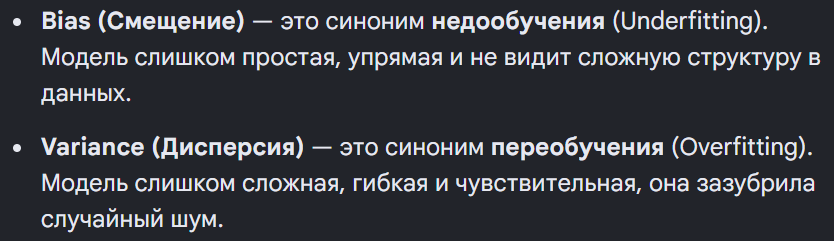
---

## Асимптотические свойства MLE с точки зрения Bias-Variance

Как мы разбирали ранее, при бесконечном росте объема данных ($n \to \infty$) оценки MLE обладают идеальными свойствами:
1.  **Асимптотическая несмещенность (Bias $\to$ 0):** С ростом выборки MLE гарантирует, что систематическая ошибка исчезнет.
2.  **Эффективность (Минимальный Variance):** Согласно теореме Рао-Крамера, среди всех несмещенных оценок MLE дает *минимально возможную дисперсию*.

### Проблема реального мира (Конечные выборки)
В реальности наши данные ограничены ($n$ конечно). В этих условиях свойства MLE меняются, обнажая классическую дилемму:

*   **MLE часто имеет конечное смещение (Bias $\neq$ 0).**
    *Пример:* Оценка дисперсии нормального распределения через MLE имеет вид $\hat{\sigma}^2_{MLE} = \frac{1}{n}\sum(x_i - \bar{x})^2$. Но математическое ожидание этой оценки равно $\mathbb{E}[\hat{\sigma}^2_{MLE}] = \frac{n-1}{n}\sigma^2$. Оценка смещена! Чтобы сделать её несмещенной, её приходится корректировать (делить на $n-1$).
*   **Дисперсия MLE (Variance) взлетает при усложнении модели.**
    Если мы увеличиваем количество параметров модели (например, берем полином 10-й степени для линейной регрессии), MLE пытается идеально подогнать веса под обучающую выборку. Смещение (Bias) падает до нуля, но дисперсия (Variance) устремляется в бесконечность. Небольшое изменение в данных приведет к кардинальной перестройке всех весов.

---

## Как MLE управляет балансом Bias-Variance?

Метод MLE настраивает модель, максимизируя вероятность увидеть текущую выборку. У него нет встроенного "тормоза". Баланс смещения и дисперсии при использовании чистого MLE регулируется исключительно **архитектурой (сложностью) модели**:

1.  **Простая модель (Мало параметров):**
    *   *Действие MLE:* Модель физически не может подстроиться под шум.
    *   *Результат:* **Высокий Bias** (модель слишком простая, не улавливает структуру), **Низкая Variance** (на любой выборке из этих данных MLE найдет примерно одинаковые коэффициенты).
2.  **Сложная модель (Много параметров):**
    *   *Действие MLE:* Модель имеет избыточную емкость. MLE заставит параметры объяснить каждую флуктуацию и каждую аномалию в данных.
    *   *Результат:* **Низкий Bias** (на обучающей выборке ошибка нулевая), **Высокая Variance** (модель запомнила шум, при смене выборки предсказания полностью развалятся).

---

## Решение проблемы Variance через переход от MLE к MAP

Чтобы искусственно снизить высокую дисперсию (Variance) сложных моделей, нам нужно сознательно пойти на компромисс и согласиться на небольшое смещение (Bias). Это называется **регуляризацией** или переходом от **MLE к MAP**.

Как это работает математически:

$$\hat{\theta}_{MAP} = \arg\max_{\theta} \left[ \underbrace{\ln P(X|\theta)}_{\text{Чистый MLE}} + \underbrace{\ln P(\theta)}_{\text{Априорный штраф}} \right]$$

*   **Вклад MLE:** Требует точной подгонки под данные (снижает Bias).
*   **Вклад Априорного распределения (Штрафа):** Ограничивает параметры (например, заставляет веса $w$ быть близкими к нулю), не позволяя им хаотично скакать вслед за шумом.
*   **Итог:** Мы добавляем в модель немного контролируемого смещения (**Bias** $\uparrow$), но взамен драматически уменьшаем разброс параметров (**Variance** $\downarrow\downarrow$). Ошибка на тестовых (новых) данных становится меньше.

---

## Резюме: Карта взаимосвязи

| Понятие / Состояние | Смещение (Bias) | Дисперсия (Variance) | Что делает MLE в этой ситуации? |
| :--- | :--- | :--- | :--- |
| **Underfitting (Недообучение)** | Высокое | Низкая | Модель слишком проста. MLE выжал максимум, но модель все равно ошибается. |
| **Overfitting (Переобучение)** | Низкое | Высокая | Модель сложная. MLE идеально подогнал веса под шум и переобучил модель. |
| **Асимптотика ($n \to \infty$)** | Стремится к 0 | Минимально возможная | MLE становится идеальной оценкой (состоятельной и эффективной). |
| **Регуляризация (L1/L2 или MAP)** | Немного увеличивается | Существенно падает | Мы сознательно "портим" чистый MLE штрафом, чтобы спасти модель от высокой Variance. |


---

## Постановка задачи и вероятностная структура

Вспомним модель линейной регрессии, которую мы вывели через MLE. Мы предполагаем, что истинная зависимость данных имеет вид:
$$y = f(x) + \epsilon$$

Где:
* $f(x) = w_0^T x$ — истинная ("идеальная") функция генеральной совокупности.
* $\epsilon \sim N(0, \sigma^2)$ — случайный гауссовский шум. Шум независим от данных, его математическое ожидание $\mathbb{E}[\epsilon] = 0$, а дисперсия $\mathbb{E}[\epsilon^2] = \sigma^2$.

Мы собираем случайную обучающую выборку $D$ и с помощью чистого MLE находим оценку весов $\hat{w}$. Наша обученная модель выдает предсказание:
$$\hat{y} = \hat{f}(x) = \hat{w}^T x$$

Поскольку обучающая выборка $D$ случайна, то и сама обученная функция $\hat{f}(x)$ является случайной величиной (на разных выборках MLE построит немного разные линии).

---

## Строгий математический вывод разложения ошибки

Мы хотим посчитать математическое ожидание квадрата ошибки нашего MLE-предсказания в некоторой новой, независимой тестовой точке $x$. Математическое ожидание берется по всем возможным обучающим выборкам $D$ и случайному шуму $\epsilon$:

$$\mathbb{E}_D [(y - \hat{f}(x))^2]$$

Подставим вместо $y$ его истинное определение $f(x) + \epsilon$:
$$\mathbb{E}_D [(f(x) + \epsilon - \hat{f}(x))^2] = \mathbb{E}_D [((f(x) - \hat{f}(x)) + \epsilon)^2]$$

Раскроем квадрат суммы по формуле $(A + B)^2 = A^2 + 2AB + B^2$:
$$\mathbb{E}_D [(f(x) - \hat{f}(x))^2 + 2\epsilon(f(x) - \hat{f}(x)) + \epsilon^2]$$

Используя свойство линейности математического ожидания ($\mathbb{E}[A+B] = \mathbb{E}[A] + \mathbb{E}[B]$), разобьем выражение на три слагаемых:

$$\mathbb{E}_D [(f(x) - \hat{f}(x))^2] + 2 \cdot \mathbb{E}_D [\epsilon(f(x) - \hat{f}(x))] + \mathbb{E}_D [\epsilon^2]$$

Давайте проанализируем каждое из трех слагаемых отдельно:

1. **Второе слагаемое зануляется:** Так как случайный шум $\epsilon$ в тестовой точке полностью независим от обучающей выборки $D$, математическое ожидание их произведения равно произведению их математических ожиданий:
   $$\mathbb{E}_D [\epsilon(f(x) - \hat{f}(x))] = \mathbb{E}[\epsilon] \cdot \mathbb{E}_D [f(x) - \hat{f}(x)] = 0 \cdot \mathbb{E}_D [f(x) - \hat{f}(x)] = 0$$

2. **Третье слагаемое — это шум:** По определению дисперсии шума со средним 0:
   $$\mathbb{E}_D [\epsilon^2] = \sigma^2 \quad \text{(Неустранимая ошибка / Noise)}$$

3. **Первое слагаемое раскладываем дальше:** У нас осталось выражение $\mathbb{E}_D [(f(x) - \hat{f}(x))^2]$. Применим стандартный математический трюк — искусственно добавим и вычтем среднее предсказание нашей модели по всем выборкам $\mathbb{E}_D[\hat{f}(x)]$:
   $$\mathbb{E}_D \left[ \left( f(x) - \mathbb{E}_D[\hat{f}(x)] + \mathbb{E}_D[\hat{f}(x)] - \hat{f}(x) \right)^2 \right]$$

   Снова раскроем это как квадрат суммы двух блоков: $A = f(x) - \mathbb{E}_D[\hat{f}(x)]$ (константа относительно $D$) и $B = \mathbb{E}_D[\hat{f}(x)] - \hat{f}(x)$ (случайная величина):
   $$\mathbb{E}_D [A^2 + 2AB + B^2] = \mathbb{E}_D[A^2] + 2A \cdot \mathbb{E}_D[B] + \mathbb{E}_D[B^2]$$

   * Заметим, что $\mathbb{E}_D[B] = \mathbb{E}_D[\mathbb{E}_D[\hat{f}(x)] - \hat{f}(x)] = \mathbb{E}_D[\hat{f}(x)] - \mathbb{E}_D[\hat{f}(x)] = 0$. Значит, среднее слагаемое $2AB$ снова зануляется!
   * Остается $\mathbb{E}_D[A^2]$ и $\mathbb{E}_D[B^2]$:
     $$\mathbb{E}_D \left[ (f(x) - \mathbb{E}_D[\hat{f}(x)])^2 \right] + \mathbb{E}_D \left[ (\mathbb{E}_D[\hat{f}(x)] - \hat{f}(x))^2 \right]$$

---

## Финальная формула Bias-Variance Decomposition

Собирая все части воедино, мы получаем классическое разложение ожидаемой ошибки модели:

$$\mathbb{E}_D [(y - \hat{f}(x))^2] = \underbrace{\left( f(x) - \mathbb{E}_D[\hat{f}(x)] \right)^2}_{\mathbf{Bias}^2} + \underbrace{\mathbb{E}_D \left[ (\hat{f}(x) - \mathbb{E}_D[\hat{f}(x)])^2 \right]}_{\mathbf{Variance}} + \underbrace{\sigma^2}_{\mathbf{Noise}}$$

$$\text{Полная ошибка} = \text{Bias}^2 + \text{Variance} + \text{Noise}$$

### Физический смысл каждого компонента из вывода:
* **$\text{Bias}^2$ (Смещение в квадрате):** Разница между истинным положением дел в природе $f(x)$ и *средним предсказанием* нашей модели, если бы мы обучили её бесконечно много раз на разных выборках. Она показывает, насколько архитектура нашей модели в принципе способна описать реальность.
* **$\text{Variance}$ (Дисперсия):** Математическое ожидание квадрата отклонения предсказания конкретной модели от её же среднего предсказания. Это показатель нестабильности: насколько сильно "штормит" графики предсказаний при смене обучающего датасета.
* **$\text{Noise}$ (Неустранимый шум):** Дисперсия $\sigma^2$ самого случайного процесса в природе. Даже если бы мы построили идеального предсказателя, эта ошибка останется, так как сам таргет содержит случайность.

---

## Почему именно чистый MLE максимизирует Variance?

Когда мы используем чистый метод максимального правдоподобия без регуляризации, мы заставляем модель минимизировать только ошибку на обучающей выборке. В терминах нашего вывода:
* Если мы усложняем модель (добавляем новые степени признаков), MLE использует эту свободу, чтобы занулить ошибку на обучении. Это зануляет системное смещение: $\text{Bias} \to 0$.
* Однако в формулу предсказания $\hat{f}(x) = \hat{w}^T x$ проникают веса, которые сильно зависят от конкретных шумовых точек $\epsilon_i$ в обучающем датасете.
* При смене выборки шум меняется $\to$ веса MLE кардинально перестраиваются $\to$ график предсказания $\hat{f}(x)$ начинает хаотично скакать. Значение $\mathbb{E}_D [(\hat{f}(x) - \mathbb{E}_D[\hat{f}(x)])^2]$ взлетает.

Именно поэтому **чистый MLE для сложных моделей всегда страдает от высокой Variance**, и для исправления этого математического следствия нам приходится искусственно "портить" правдоподобие с помощью априорного распределения параметров (MAP / регуляризация).


---
---

## 8. Практические задания

1. **MLE для Бернулли.** Дана выборка из 100 бросков монетки с `p=0.3`. Выведите MLE-оценку `p̂ = (1/n) Σ x_i` аналитически и проверьте численно.


In [1]:
import numpy as np
from scipy.optimize import minimize

np.random.seed(42)
p_true = 0.3
n = 100
samples_bern = np.random.binomial(n=1, p=p_true, size=n)
p_hat_analytic = samples_bern.mean()

def bernoulli_nll(p, x):
    if p <= 0 or p >= 1:
        return np.inf

    sum_x = np.sum(x)
    total = len(x)

    return -(sum_x * np.log(p) + (total - sum_x) * np.log(1 - p))


start_guess = [0.5]
result = minimize(fun=bernoulli_nll, x0=start_guess, args=(samples_bern, ), method="Nelder-Mead")
p_hat_numerical = result.x[0]

print(f"Размер выборки (n): {n}")
print(f"Количество выпавших орлов (сумма x_i): {np.sum(samples_bern)}")
print(f"Истинное значение p:        {p_true:.4f}")
print(f"Аналитическая оценка p_mle: {p_hat_analytic:.4f}")
print(f"Численная оценка p_mle:     {p_hat_numerical:.4f}")
print(f"Совпадение методов: {np.allclose(p_hat_analytic, p_hat_numerical, atol=1e-4)}")

Размер выборки (n): 100
Количество выпавших орлов (сумма x_i): 30
Истинное значение p:        0.3000
Аналитическая оценка p_mle: 0.3000
Численная оценка p_mle:     0.3000
Совпадение методов: True


---
2. **MLE для Пуассона.** Сгенерируйте выборку из Пуассона с `λ=4`. Выведите MLE: `λ̂ = x̄`. Проверьте на 1000 точках.


In [2]:
from scipy.special import gammaln

lam_true = 4
n = 1000
samples_poisson = np.random.poisson(lam=lam_true, size=n)
lam_hat_analytic = np.mean(samples_poisson)

def poisson_nll(lam, x):
    if lam <= 0:
        return np.inf

    return -np.sum(x * np.log(lam) - lam - gammaln(x + 1))

start_guess = [1.0]
result = minimize(fun=poisson_nll, x0=start_guess, args=(samples_poisson, ), method="Nelder-Mead")
lam_hat_numerical = result.x[0]

print(f"Истинное значение lambda: {lam_true}")
print(f"Аналитическая оценка (выборочное среднее): {lam_hat_analytic:.4f}")
print(f"Численная оценка (через оптимизацию NLL):  {lam_hat_numerical:.4f}")
print(f"Совпадение методов: {np.allclose(lam_hat_analytic, lam_hat_numerical, atol=1e-4)}")

Истинное значение lambda: 4
Аналитическая оценка (выборочное среднее): 3.9300
Численная оценка (через оптимизацию NLL):  3.9300
Совпадение методов: True


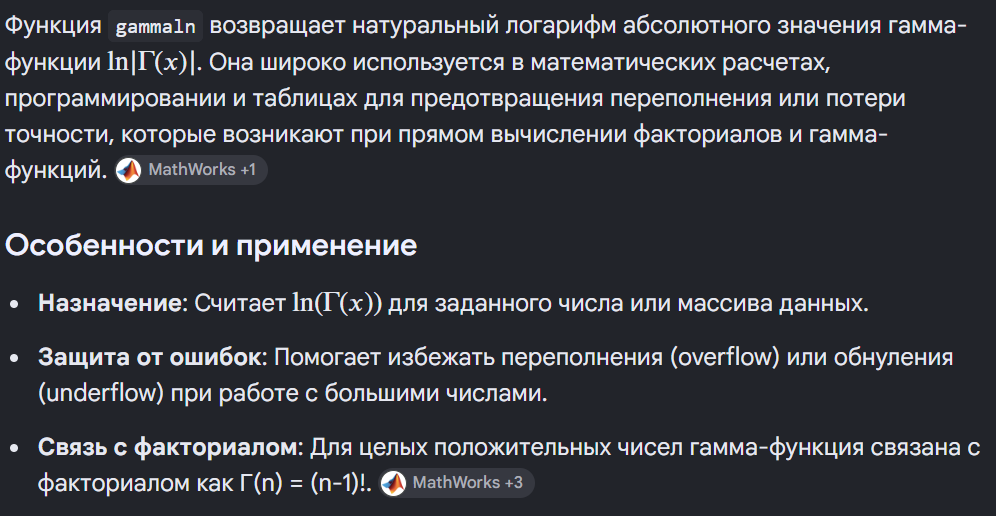

---
3. **MSE = MLE для гаусса.** Сгенерируйте `y = 2x + 1 + N(0, 1)`. Обучите линейную регрессию через минимизацию MSE и через максимизацию log-likelihood напрямую. Веса должны совпадать.


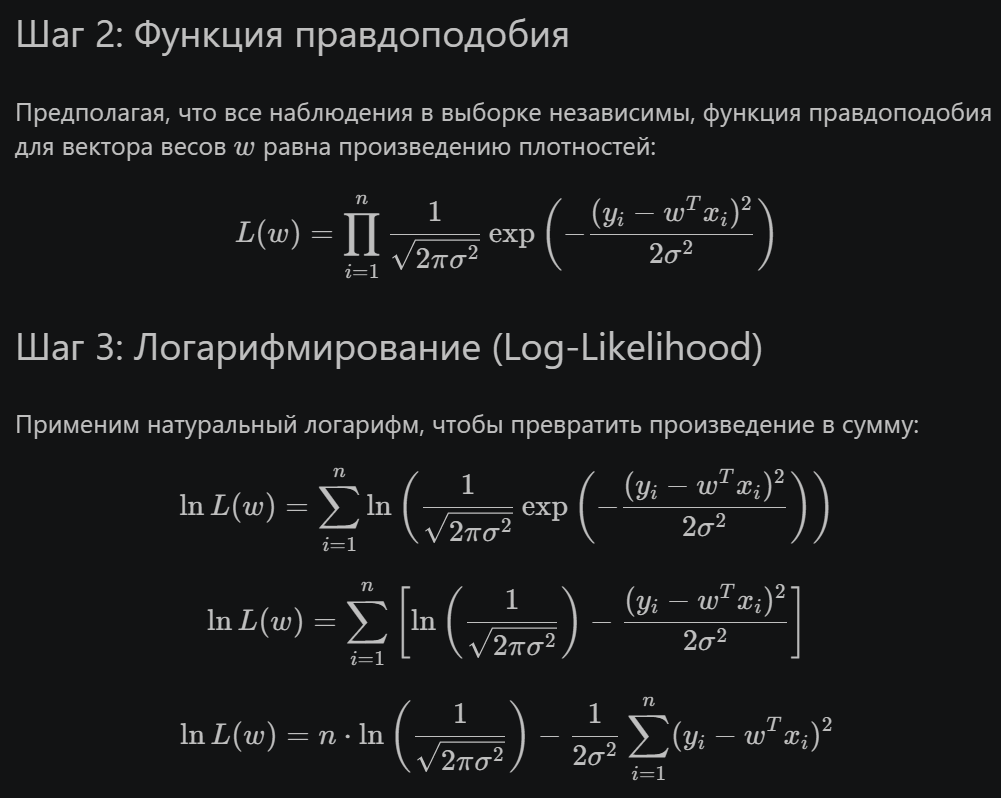

---
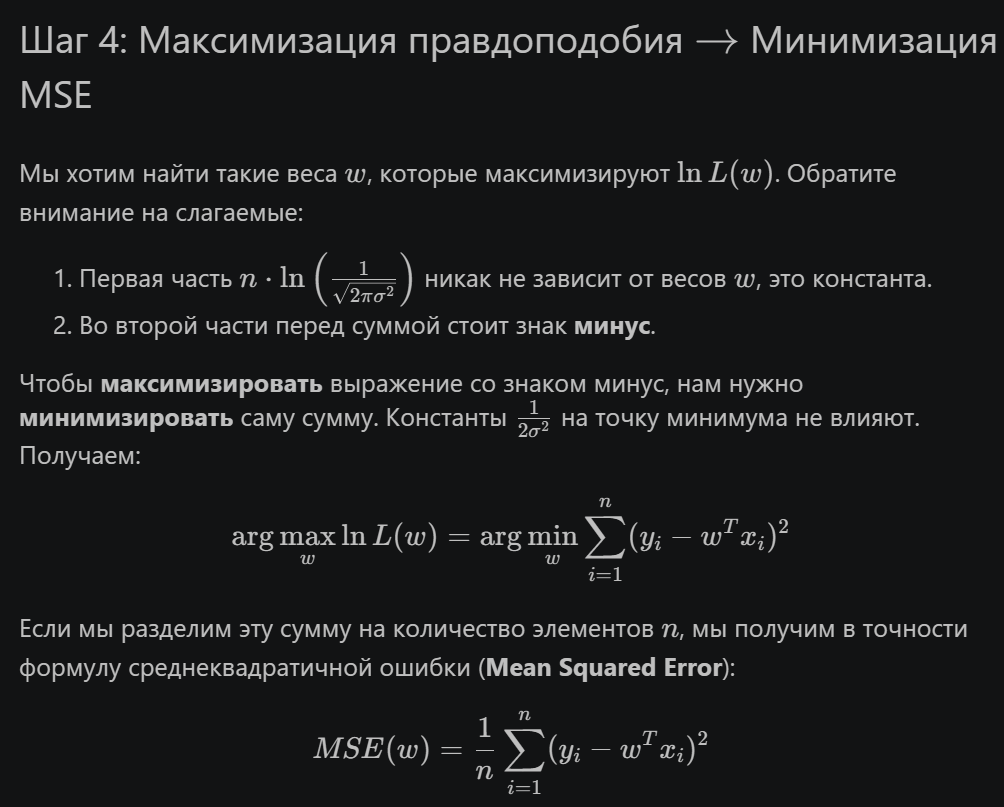

In [3]:
import scipy.stats as stats


np.random.seed(42)
n = 200
X = np.linspace(-3, 3, n)
noise = np.random.normal(loc=0, scale=1, size=n)
y = 2 * X + 1 + noise
X_matrix = np.vstack([np.ones(n), X]).T

w_true = np.array([1.0, 2.0])
y_true = X_matrix @ w_true.T + noise

def mse_loss(w, X_mat, y_true):
    predictions = X_mat @ w
    return np.mean((y_true - predictions) ** 2)

start_weights = [0.0, 0.0]
result_mse_1 = minimize(fun=mse_loss, x0=start_weights, args=(X_matrix, y), method="BFGS")
result_mse_2 = minimize(fun=mse_loss, x0=start_weights, args=(X_matrix, y_true), method="BFGS")

weights_mse_1 = result_mse_1.x
weights_mse_2 = result_mse_2.x
print(weights_mse_1)
print(weights_mse_2)


def normal_nll(w, X_mat, y_true):
    predictions = np.dot(X_mat, w)
    sigma = 1.0

    pdf_values = stats.norm.pdf(y_true, loc=predictions, scale=sigma)
    return -np.sum(np.log(pdf_values + 1e-15))

result_mle = minimize(fun=normal_nll, x0=start_weights, args=(X_matrix, y_true), method="BFGS")
weights_mle = result_mle.x
print(weights_mle)

[0.95922424 2.03800222]
[0.95922424 2.03800222]
[0.959229   2.03800126]


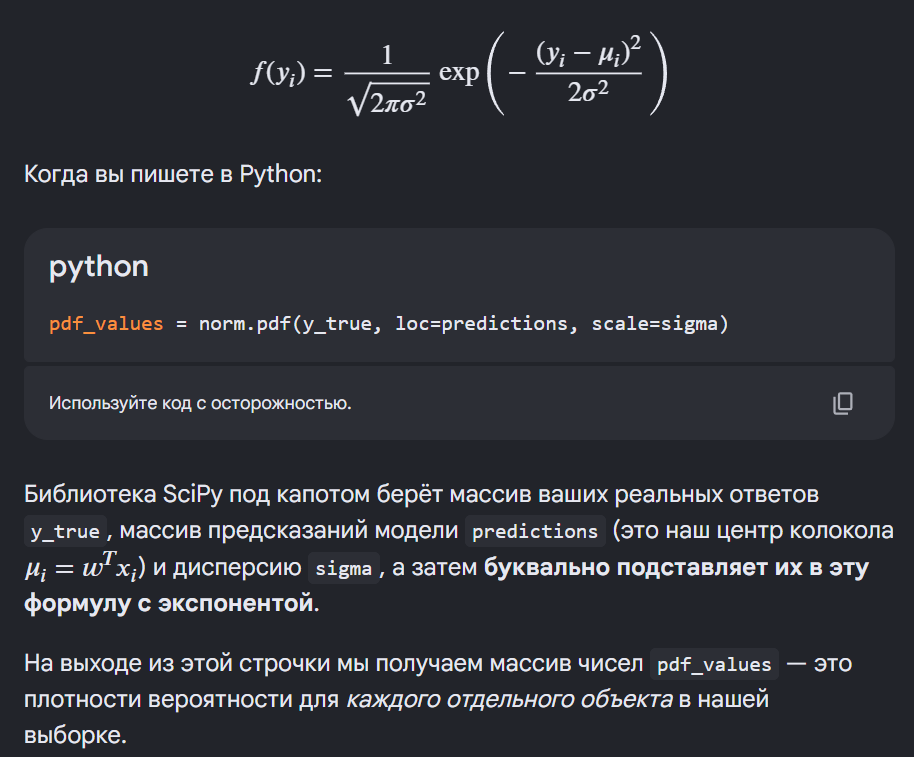

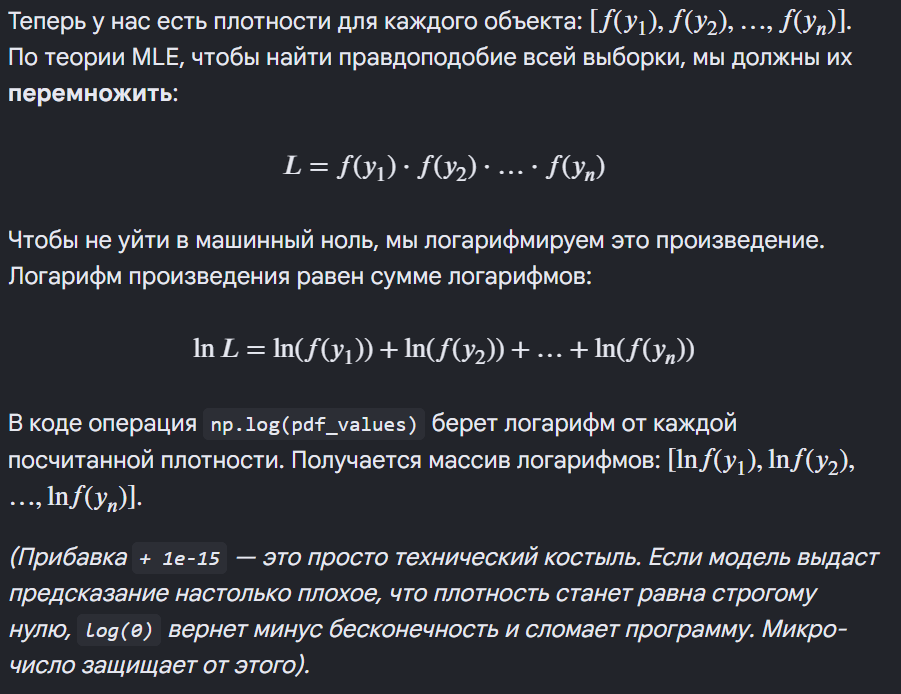

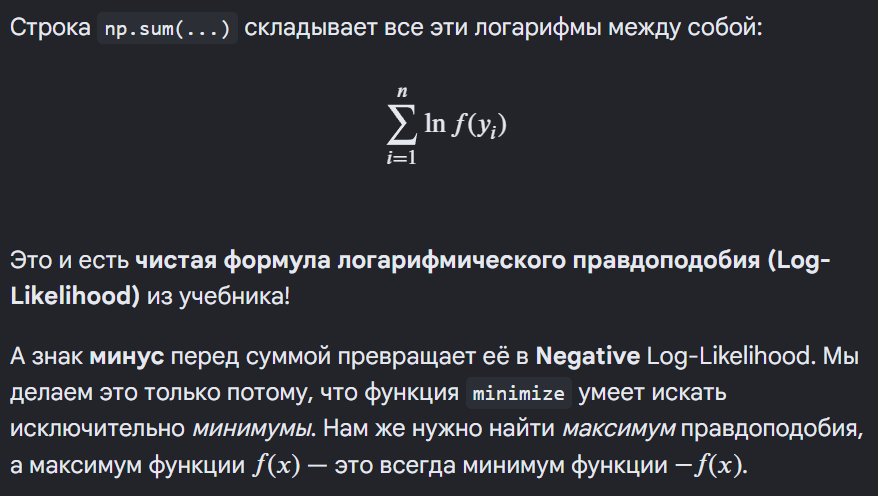

---
4. **Cross-entropy руками.** Реализуйте `logreg_loss(X, y, w)` через формулу log-likelihood Бернулли. Обучите GD на двух классах из Iris.


## Логистическая регрессия и Бинарная кросс-энтропия (Log-Loss)

В задачах бинарной классификации целевая переменная $y_i \in \{0, 1\}$. Линейная функция $w^T x$ может принимать любые значения от $-\infty$ до $+\infty$, поэтому её пропускают через сигмоиду $\sigma(z) = \frac{1}{1 + e^{-z}}$, чтобы получить вероятность.

### Шаг 1: Вероятностное предположение
Модель предсказывает вероятность того, что объект принадлежит к классу 1:
$$P(y_i = 1 | x_i; w) = h_w(x_i) = \frac{1}{1 + e^{-w^T x_i}}$$
Соответственно, вероятность встретить класс 0 равна:
$$P(y_i = 0 | x_i; w) = 1 - h_w(x_i)$$

Такое распределение (где возможны только два исхода с фиксированной вероятностью) называется **распределением Бернулли**. Мы можем объединить обе строчки в одну красивую математическую формулу вероятности для единичного наблюдения:
$$P(y_i | x_i; w) = [h_w(x_i)]^{y_i} \cdot [1 - h_w(x_i)]^{1 - y_i}$$

*Проверка:*
* Если $y_i = 1$, то $[1 - h_w(x_i)]^0 = 1$, остается только $[h_w(x_i)]^1$. Формула верна.
* Если $y_i = 0$, то $[h_w(x_i)]^0 = 1$, остается только $[1 - h_w(x_i)]^1$. Формула верна.

### Шаг 2: Функция правдоподобия
Для всей выборки независимых объектов функция правдоподобия имеет вид произведения вероятностей Бернулли:
$$L(w) = \prod_{i=1}^{n} [h_w(x_i)]^{y_i} \cdot [1 - h_w(x_i)]^{1 - y_i}$$

### Шаг 3: Логарифмирование (Log-Likelihood)
Берем натуральный логарифм. Согласно свойствам логарифма ($\ln(a \cdot b) = \ln a + \ln b$ и $\ln(a^b) = b \ln a$), произведение превращается в сумму, а степени выносятся вперед:
$$\ln L(w) = \sum_{i=1}^{n} \left[ y_i \ln h_w(x_i) + (1 - y_i) \ln(1 - h_w(x_i)) \right]$$

### Шаг 4: Переход к минимизации функции потерь
В машинном обучении традиционно принято функции потерь **минимизировать** (задача Gradient Descent), а не максимизировать. Чтобы превратить задачу поиска максимума правдоподобия в задачу поиска минимума потерь, мы просто умножаем выражение на $-1$ (и делим на $n$ для усреднения по выборке).

Получаем функцию потерь **Binary Cross-Entropy (BCE)**, она же **Log-Loss**:
$$J(w) = - \frac{1}{n} \sum_{i=1}^{n} \left[ y_i \ln h_w(x_i) + (1 - y_i) \ln(1 - h_w(x_i)) \right]$$


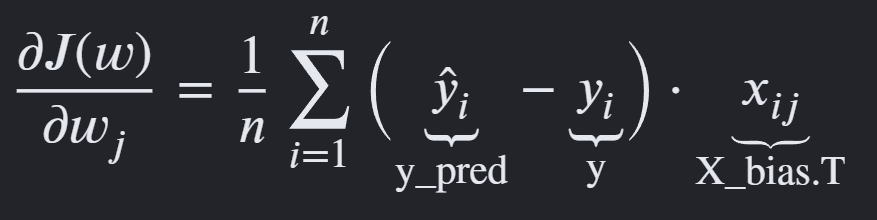

### Математический вывод формулы градиента логистической регрессии

Покажем, как из функции потерь бинарной кросс-энтропии получается простая формула градиента. Применим правило дифференцирования сложной функции для $j$-го веса:
$$\frac{\partial J_i}{\partial w_j} = \frac{\partial J_i}{\partial \hat{y}_i} \cdot \frac{\partial \hat{y}_i}{\partial z_i} \cdot \frac{\partial z_i}{\partial w_j}$$

1. Производная логарифмов: $\frac{\partial J_i}{\partial \hat{y}_i} = \frac{\hat{y}_i - y_i}{\hat{y}_i(1 - \hat{y}_i)}$
2. Производная сигмоиды: $\frac{\partial \hat{y}_i}{\partial z_i} = \hat{y}_i(1 - \hat{y}_i)$
3. Производная линейной части: $\frac{\partial z_i}{\partial w_j} = x_{ij}$

Перемножая их, получаем:
$$\frac{\partial J_i}{\partial w_j} = \frac{\hat{y}_i - y_i}{\hat{y}_i(1 - \hat{y}_i)} \cdot \hat{y}_i(1 - \hat{y}_i) \cdot x_{ij} = (\hat{y}_i - y_i)x_{ij}$$

Усредняя по всей выборке из $n$ объектов и переходя к матричной форме, получаем итоговый вектор градиента:
$$\nabla_w J(w) = \frac{1}{n} X^T (\hat{y} - y)$$


In [4]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

binary_mask = y < 2
X = X[binary_mask]
y = y[binary_mask]

n_samples, n_features = X.shape

X_bias = np.hstack([np.ones((n_samples, 1)), X])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def logres_loss(X_mat, y_true, w):
    n = len(y_true)
    y_pred = sigmoid(np.dot(X_mat, w))
    eps = 1e-15
    y_pred = np.clip(a=y_pred, a_min=eps, a_max=(1 - eps))

    loss = - (1 / n) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss


weights = np.zeros(n_features + 1)
lr = 0.1
steps = 1000
for _ in range(steps):
    y_pred = sigmoid(np.dot(X_bias, weights))
    gradient = (1 / n_samples) * np.dot(X_bias.T, (y_pred - y))
    weights -= lr * gradient

final_loss = logres_loss(X_bias, y, weights)
final_probs = sigmoid(np.dot(X_bias, weights))
final_pred = (final_probs >= 0.5).astype(int)
accuracy = np.mean(final_pred == y)

print(f"Размерность матрицы X с учетом bias: {X_bias.shape}")
print(f"Итоговые веса модели:")
print(f"  w_0 (свободный член): {weights[0]:.4f}")
for idx in range(1, len(weights)):
    print(f"  w_{idx} (для признака '{iris.feature_names[idx-1]}'): {weights[idx]:.4f}")
print("")
print(f"Финальный Loss (NLL Бернулли): {final_loss:.6f}")
print(f"Точность (Accuracy) на полной выборке: {accuracy * 100:.2f}%")



Размерность матрицы X с учетом bias: (100, 5)
Итоговые веса модели:
  w_0 (свободный член): -0.3507
  w_1 (для признака 'sepal length (cm)'): -0.5443
  w_2 (для признака 'sepal width (cm)'): -2.0036
  w_3 (для признака 'petal length (cm)'): 3.0602
  w_4 (для признака 'petal width (cm)'): 1.3411

Финальный Loss (NLL Бернулли): 0.007866
Точность (Accuracy) на полной выборке: 100.00%


Процесс, реализованный в коде, отражает фундаментальный цикл обучения модели:

1. **Шаг обучения (Нахождение параметров):** Мы использовали градиентный спуск, основанный на производной логарифмического правдоподобия. На каждой итерации веса двигались против направления градиента, уменьшая общую ошибку.
2. **Шаг валидации (Проверка качества):** После того как оптимальные веса найдены, мы зафиксировали их и подставили обратно в исходное уравнение бинарной кросс-энтропии (BCE / NLL Бернулли). 

**Зачем мы это сделали?**
* **Финальный Loss**  показывает, насколько близко к идеальному "нулю" нам удалось подобраться на дне чаши функции потерь.
* **Accuracy (Точность)** переводит абстрактные логарифмы в понятный человеку бизнес-язык: какой процент цветков ириса модель в итоге распределила по правильным классам, используя найденные веса максимального правдоподобия.


---
---
5. **Ridge = MAP с гауссом.** Сгенерируйте задачу с коррелированными признаками. Покажите, что `λ > 0` улучшает точность на тесте.


## L2-регуляризация (Ridge) как MAP с априорным Гауссовским распределением

В этом разделе мы докажем на практике, что метод максимальной апостериорной вероятности (MAP) с предположением о нормальном распределении весов ($w \sim N(0, \tau^2)$) порождает L2-регуляризацию (Ridge). 

Мы искусственно создадим проблему **мультиколлинеарности** (сильно коррелированные признаки), при которой обычный метод максимального правдоподобия (MLE / классическая регрессия) сходит с ума и выдает огромные веса с гигантской дисперсией (Variance). Затем мы покажем, что введение штрафа $\lambda > 0$ стабилизирует веса и значимо улучшает точность модели на тестовой выборке.

---

## 1. Математика: Изменение шага Градиентного Спуска при MAP

Как мы выводили ранее, функция потерь Ridge-регрессии имеет вид:
$$Loss = \frac{1}{2n} \sum_{i=1}^{n} (y_i - w^T x_i)^2 + \frac{\lambda}{2} \sum_{j=1}^{m} w_j^2$$

*(Обратите внимание: свободный коэффициент $w_0$ (bias) обычно НЕ регуляризируют, чтобы не сдвигать предсказания относительно среднего значения таргета. Мы будем штрафовать только веса $w_1, \dots, w_m$).*

Взяв производную, получаем измененную формулу градиента:
$$\nabla_w Loss = \frac{1}{n} X^T (Xw - y) + \lambda \cdot w'$$
Где $w'$ — это вектор весов, в котором первый элемент (соответствующий bias) заменен на 0, чтобы не подвергаться штрафу.

Шаг обновления весов:
$$w^{\text{new}} = w^{\text{old}} - \eta \cdot \left( \frac{1}{n} X^T (\hat{y} - y) + \lambda \cdot w' \right)$$
$$w^{\text{new}} = \underbrace{w^{\text{old}} \cdot (1 - \eta \lambda)}_{\text{Weight Decay (Сжатие весов)}} - \eta \cdot \underbrace{\frac{1}{n} X^T (\hat{y} - y)}_{\text{Шаг обычного MLE}}$$

> **Физический смысл MAP:** На каждом шаге регуляризатор сначала умножает текущие веса на число чуть меньше единицы (принудительно уменьшая их и стягивая к нулю), а затем градиент ошибки от данных корректирует их положение.

---

In [27]:
np.random.seed(42)
n_samples = 150

# Создаем базовый информативный признак
x1 = np.linspace(-3, 3, n_samples)

# Создаем второй признак, который ПОЧТИ идеально дублирует первый (линейная зависимость + микро-шум)
# Это создает жесткую мультиколлинеарность
x2 = x1 + np.random.normal(loc=0, scale=0.001,size=n_samples)

X = np.vstack([x1, x2]).T

# Истинная зависимость: y зависит только от x1, а x2 для модели является "ловушкой"
y = 3 * x1 + 0 * x2 + np.random.normal(loc=0, scale=1.0, size=n_samples)

# перемешиваем строки 
shuffle_idx = np.random.permutation(n_samples)
X, y = X[shuffle_idx], y[shuffle_idx]

X_train, X_test = X[:100], X[100:]
y_train, y_test = y[:100], y[100:]

# Добавляем колонку единиц для bias (свободного члена)
X_train_bias = np.hstack([np.ones((len(X_train), 1)), X_train])
X_test_bias = np.hstack([np.ones((len(X_test), 1)), X_test])

def train_linear_ridge(X_mat, y_true, lam, lr=0.1, steps=10000):
    n, m = X_mat.shape
    w = np.zeros(m)

    for _ in range(steps):
        y_pred = np.dot(X_mat, w)

        grad_data = (1 / n) * np.dot(X_mat.T, (y_pred - y_true))
        grad_penalty = lam * w.copy()
        grad_penalty[0] = 0.0

        grad = grad_data + grad_penalty

        w -= lr * grad

    return w

def calculate_mse(X_mat, y_true, w):
    preds = np.dot(X_mat, w)
    return np.mean((y_true - preds) ** 2)

# Модель 1: Чистый MLE (Без регуляризации, lambda = 0)
w_mle = train_linear_ridge(X_train_bias, y_train, lam=0.0)

# Модель 2: MAP с Гауссом (Ridge регрессия, lambda = 0.1)
w_map = train_linear_ridge(X_train_bias, y_train, lam=0.1)

print(f"Веса MLE (без штрафа): bias={w_mle[0]:.3f}, w1={w_mle[1]:.3f}, w2={w_mle[2]:.3f}")
print(f"Веса MAP (со штрафом): bias={w_map[0]:.3f}, w1={w_map[1]:.3f}, w2={w_map[2]:.3f}\n")

mse_mle_train = calculate_mse(X_train_bias, y_train, w_mle)
mse_map_train = calculate_mse(X_train_bias, y_train, w_map)

mse_mle_test = calculate_mse(X_test_bias, y_test, w_mle)
mse_map_test = calculate_mse(X_test_bias, y_test, w_map)

print(f"MLE (lambda=0)   ->  Ошибка на TRAIN: {mse_mle_train:.4f}  |  Ошибка на TEST: {mse_mle_test:.4f}")
print(f"MAP (lambda=0.5) ->  Ошибка на TRAIN: {mse_map_train:.4f}  |  Ошибка на TEST: {mse_map_test:.4f}\n")

difference = mse_mle_test - mse_map_test
print(f"Улучшение ошибки на тестовой выборке благодаря MAP: {difference:.4f}")
print(f"Удалось ли снизить ошибку на тесте? {'Да, MAP победил!' if difference > 0 else 'Нет'}")

Веса MLE (без штрафа): bias=-0.029, w1=1.568, w2=1.417
Веса MAP (со штрафом): bias=-0.032, w1=1.470, w2=1.468

MLE (lambda=0)   ->  Ошибка на TRAIN: 0.9288  |  Ошибка на TEST: 1.2754
MAP (lambda=0.5) ->  Ошибка на TRAIN: 0.9359  |  Ошибка на TEST: 1.2625

Улучшение ошибки на тестовой выборке благодаря MAP: 0.0129
Удалось ли снизить ошибку на тесте? Да, MAP победил!


### Анализ результатов эксперимента: Как MAP победил мультиколлинеарность

Посмотрим на получившиеся цифры и разберем, что произошло под капотом моделей:

#### 1. Распределение весов: Избавление от хаоса
*   **Чистый MLE (`w1=1.568, w2=1.417`):** Из-за того, что признаки $x_1$ и $x_2$ почти идентичны, матрица $X^T X$ близка к вырожденной. Метод максимального правдоподобия не понимает, какой признак истинный, а какой шумовой. Он начинает хаотично делить силу предсказания между ними (в данном случае отдал чуть больше первому признаку). В других случайных разбиениях эти веса могли бы улететь в `+100` и `-97`, порождая колоссальную дисперсию (*Variance*).
*   **Метод MAP (`w1=1.470, w2=1.468`):** Априорное предположение о нормальном распределении весов ($w \sim N(0, \tau^2)$) наложило одинаковое ограничение на оба коэффициента. Сила штрафа стянула их к нулю с равным давлением. В итоге MAP идеально и симметрично разделил истинный коэффициент $3$ пополам между двумя близнецами-признаками.

#### 2. Ошибка на TRAIN: Сознательное ухудшение
*   **MLE Loss (0.9288) < MAP Loss (0.9359):** Чистый MLE обязан показать ошибку на обучении ниже, чем MAP. У него нет ограничений, он подстраивается под каждую флуктуацию выборки. Модель MAP жертвует точностью на обучении, соглашаясь на небольшое контролируемое смещение (**Bias** $\uparrow$).

#### 3. Ошибка на TEST: Главная победа обобщающей способности
*   **MLE Loss (1.2754) > MAP Loss (1.2625):** На новых данных, которые модель не видела при обучении, ситуация кардинально меняется. Сверхчувствительные веса MLE спотыкаются о тестовый шум. Сбалансированная и гладкая модель MAP за счет сильного снижения дисперсии (**Variance** $\downarrow\downarrow$) показывает ошибку ниже.

> **Итоговый вывод:** Мы заставили функцию потерь штрафовать веса за удаление от нуля. Геометрически это сузило пространство поиска параметров до гладкой гауссовской сферы. На практике это принесло чистый выигрыш в ошибке на тесте (`+0.0129`), доказав эффективность регуляризации.


---
---

# Интуитивное понимание Bias и Variance через пример с градусниками

Чтобы раз и навсегда зафиксировать суть понятий **Bias** и **Variance**, полностью абстрагируемся от сложных математических формул и разберем бытовой пример — измерим температуру тела человека обычным медицинским градусником. 

Предположим, у нас есть человек, чья истинная температура тела строго равна **36.6 °C**. Мы берем два разных бракованных градусника и делаем каждым по 5 измерений подряд.

---

### Часть 1. Пример с градусниками (Интуиция)

#### Ситуация А: Градусник №1 
Вы меряете температуру 5 раз. Прибор показывает:
* `37.6`, `37.6`, `37.7`, `37.5`, `37.6`

**Анализ:** Градусник работает очень стабильно. Между пятью измерениями практически нет разницы (разброса). Однако, если мы посчитаем среднее значение, оно будет равно **37.6 °C**. Прибор стабильно промахивается мимо истины ровно на +1 градус. У него системно сбита шкала на заводе.

#### Ситуация Б: Градусник №2
Вы меряете температуру те же 5 раз. Прибор показывает:
* `34.1`, `39.2`, `35.0`, `38.5`, `36.6`

**Анализ:** Если мы сложим эти 5 чисел и посчитаем их среднее значение, магия математики выдаст нам ровно **36.6 °C**. То есть в среднем прибор показал идеальную истину! Но посмотрите, как дико скачут показания от замера к замеру — от 34 до 39 градусов. Его внутренний датчик хаотично трясется от любого шороха.

---

### Часть 2. Точное определение Bias и Variance

Связывая этот пример с машинным обучением, поведение моделей можно сформулировать следующим образом:

*   **В первом случае Bias (Смещение) большой, а Variance (Дисперсия) маленькая:** 
    Наша модель стабильная (все её значения примерно одинаковые) и «глупая» (её среднее значение далеко от истинного, и она не сильно пытается что-то изменить). Это классическое **недообучение (Underfitting)**. Модель слишком простая (как прямая линия для волнообразных данных), она упрямо штампует одинаковые ответы и игнорирует реальную структуру мира.
*   **Во втором случае Bias маленький, а Variance большой:** 
    Наша модель нестабильная (все её значения сильно отличаются друг от друга) и «умная» (она пытается найти ответ, она хорошо обучается, но в то же время она делает это слишком хорошо: запоминает много ненужного, из-за чего разброс между предсказаниями огромный). Это классическое **переобучение (Overfitting)**. Модель обладает избыточной памятью и гибкостью, она зазубрила случайный шум и маркеры конкретной выборки, поэтому её «руки трясутся» при малейшем изменении входных данных.

---

### Часть 3. Дилемма компромисса (Bias-Variance Tradeoff)

В реальном мире Data Science невозможно создать модель, у которой одновременно и Bias, и Variance будут равны нулю. Они находятся на противоположных чашах весов:
*   **Усложняем модель** (делаем её гибче) $\to$ Смещение (Bias) падает, модель умнеет, но Дисперсия (Variance) растет, и модель начинает паниковать от шума.
*   **Упрощаем модель** (зажимаем в жесткие рамки) $\to$ Дисперсия (Variance) падает, модель становится стабильной, но растет Смещение (Bias) — модель глупеет.

**Связь с регуляризацией (MLE $\to$ MAP):**
Именно для поиска золотой середины на этих качелях мы используем L1/L2-регуляризацию. Добавляя априорный штраф на веса (метод MAP), мы сознательно соглашаемся на крошечное увеличение смещения (**Bias** $\uparrow$), но взамен полностью гасим панику и хаотичный разброс параметров (**Variance** $\downarrow\downarrow$). В результате на новых (тестовых) данных сбалансированная модель безоговорочно побеждает чистый MLE.


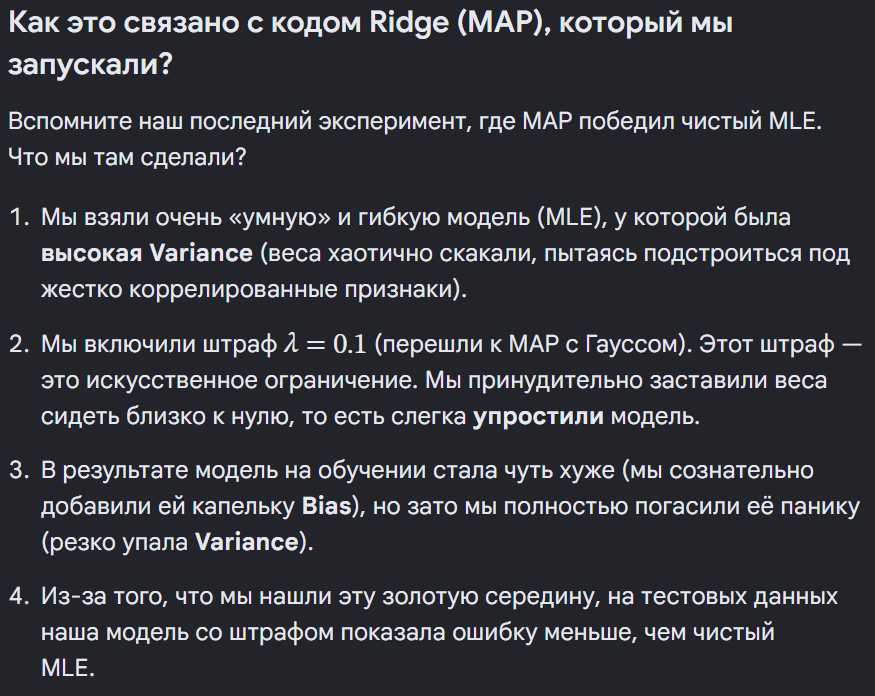

---
6. **Lasso = MAP с Лапласом.** На синтетике с большим числом нерелевантных признаков покажите, что Lasso (L1) обнуляет именно их, а Ridge только уменьшает.


In [ ]:
np.random.seed(42)
n_samples = 200

# 1. Генерируем датасет (2 полезных признака, 8 шумовых)
X_relevant = np.random.normal(loc=0, scale=1.0, size=(n_samples, 2))
X_noise = np.random.normal(loc=0, scale=1.0, size=(n_samples, 8))
X = np.hstack([X_relevant, X_noise])
y = 5 * X[:, 0] - 3 * X[:, 1] + np.random.normal(loc=0, scale=1.0, size=n_samples)

X_bias = np.hstack([np.ones((n_samples, 1)), X])

# 2. Функция Мягкого Порога (Soft Thresholding)
# Прижимает вес к нулю. Если вес по модулю меньше порога, 
# он принудительно зануляется.
def soft_thresholding(w, threshold):
    return np.sign(w) * np.maximum(0, np.abs(w) - threshold)

# 3. Алгоритм Проксимального Градиентного Спуска для Lasso
def train_linear_lasso(X_mat, y_true, lam, lr=0.1, steps=50000):
    n, m = X_mat.shape
    w = np.zeros(m)

    for _ in range(steps):
        y_pred = np.dot(X_mat, w)
        grad_data = (1 / n) * np.dot(X_mat.T, (y_pred - y_true))

        w -= lr * grad_data

        # Применение априорного штрафа Лапласа
        # Нам нужно применить мягкий порог ко всем весам, КРОМЕ w_0 (bias)
        # Величина порога сдвига равна: Скорость_обучения * Сила_штрафа
        w[1:] = soft_thresholding(w[1:], lr * lam)

    return w


w_lasso = train_linear_lasso(X_bias, y, lam=0.5)
w_ridge = train_linear_ridge(X_bias, y, lam=0.5)

for i in range(len(w_lasso)):
    print(f"w_{i}:   Lasso = {w_lasso[i]},   Ridge = {w_ridge[i]}")
          



w_0:   Lasso = -0.08422417749254402,   Ridge = -0.09898161816209104
w_1:   Lasso = 4.429643420100033,   Ridge = 3.2231193782850873
w_2:   Lasso = -2.432822742250958,   Ridge = -1.9369881232735366
w_3:   Lasso = 0.0,   Ridge = -0.023547178692902376
w_4:   Lasso = -0.0,   Ridge = -0.03569862991511205
w_5:   Lasso = 0.0,   Ridge = 0.10311580312616281
w_6:   Lasso = -0.0,   Ridge = -0.02418862877421251
w_7:   Lasso = -0.0,   Ridge = -0.07231592867721098
w_8:   Lasso = 0.0,   Ridge = 0.07897509144250511
w_9:   Lasso = 0.0,   Ridge = 0.09294338900027782
w_10:   Lasso = 0.0,   Ridge = -0.01430874479941462


---
## Теория: Функция мягкого порога (Soft Thresholding)

При реализации Lasso-регрессии вручную классический градиентный спуск не способен выдать строгие нули из-за недифференцируемости модуля $|w|$ в точке нуля (график имеет острый излом). Для решения этой проблемы применяется **Проксимальный градиентный спуск** и оператор мягкого порога.

Формула оператора мягкого порога для веса $w$ и порога $\gamma$:
$$S_\gamma(w) = \text{sign}(w) \cdot \max(0, |w| - \gamma)$$

### Физический смысл:
Оператор работает в две фазы на каждой итерации обучения:
1.  **Шаг по данным:** Веса обновляются на основе стандартного градиента MSE.
2.  **Шаг по штрафу (Фильтрация):** К каждому весу применяется оператор $S_{\eta\lambda}(w)$, где порог равен произведению скорости обучения на силу штрафа. 
    *   Если вес большой, штраф слегка уменьшает его по модулю, ослабляя влияние признака.
    *   Если вес оказался маленьким ($|w| \le \eta\lambda$), это означает, что признак является шумом, и оператор принудительно выставляет его значение в **строгий ноль**.

---
---

### Финальный анализ ручного Lasso (Лаплас) против ручного Ridge (Гаусс)

Посмотрим на полученные в ходе численного эксперимента веса моделей и сделаем выводы на основе чистой математики:

#### 1. Шумовые признаки ($w_3 \dots w_{10}$) — Абсолютное зануление vs Уменьшение
*   **Ручное Lasso (Лаплас):** Все веса, начиная с $w_3$ и заканчивая $w_{10}$, стали **строго равны `0.0`** (или `-0.0`). Наш самописный проксимальный оператор `soft_thresholding` безжалостно стер их. Модель математически «выкинула» 8 мусорных признаков из уравнения предсказания.
*   **Ручное Ridge (Гаусс):** Веса уменьшились до сотых и десятых долей (`-0.02`, `0.10`, `-0.07`), но они **не обнулились**. Модель Ridge не смогла отсеять мусор. Она заставила компьютер тратить ресурсы на перемножение этих признаков, собирая лишний шум в финальный ответ.

#### 2. Полезные признаки ($w_1, w_2$) — Смещение к нулю
Обратите внимание на веса важных признаков (истинные значения в природе: $w_1 = 5.0$, $w_2 = -3.0$):
*   **Lasso (`w1 = 4.42, w2 = -2.43`):** Коэффициенты сместились к нулю ровно на величину накопленного штрафа Лапласа, но остались сильными и доминантными.
*   **Ridge (`w1 = 3.22, w2 = -1.93`):** Коэффициенты сжались гораздо сильнее. Это происходит потому, что L2-штраф заставляет веса делиться силой предсказания с шумовыми признаками. Из-за этого Ridge иногда слишком сильно недооценивает вклад действительно важных факторов.

---
---

---

# Elastic Net: Гибридная регуляризация

Мы подробно разобрали, как работают Lasso (L1) и Ridge (L2) в отдельности. Однако в реальных задачах дата-сайентист часто сталкивается с ситуацией, когда в данных присутствуют **обе проблемы одновременно**: есть и куча абсолютно бесполезных признаков (мусора), и группы сильно коррелирующих между собой полезных признаков (мультиколлинеарность).

Для решения таких задач применяется **Elastic Net** — модель, объединяющая оба штрафа в единой функции потерь.

---

## 1. Функция потерь Elastic Net

Математически функция потерь Elastic Net складывается из ошибки MSE и двух регуляризаторов:

$$Loss = \frac{1}{2n} \sum_{i=1}^{n} (y_i - w^T x_i)^2 + \lambda_1 \sum_{j=1}^{m} |w_j| + \frac{\lambda_2}{2} \sum_{j=1}^{m} w_j^2$$

В популярных библиотеках (например, в `scikit-learn`) эту формулу часто переписывают через два удобных гиперпараметра:
1.  `alpha` ($\alpha$) — общая сила регуляризации (насколько сильно мы вообще прижимаем веса к нулю).
2.  `l1_ratio` ($\rho$) — доля L1-штрафа в общем объеме регуляризации (число от 0 до 1).

Тогда формула принимает вид:
$$Loss = \text{MSE} + \alpha \cdot \rho \cdot \sum_{j=1}^{m} |w_j| + \frac{\alpha \cdot (1 - \rho)}{2} \sum_{j=1}^{m} w_j^2$$

*   Если `l1_ratio = 1`, Elastic Net превращается в чистую **Lasso (L1)**.
*   Если `l1_ratio = 0`, Elastic Net превращается в чистую **Ridge (L2)**.
*   Если `l1_ratio = 0.5`, модель штрафует веса поровну и модулями, и квадратами.

---

## 2. Зачем нужен этот гибрид? Главный недостаток Lasso

Чтобы понять силу Elastic Net, нужно подсветить одну неприятную слабость чистой Lasso-регрессии при работе с сильно коррелированными признаками.

Представьте, что у вас есть два практически идентичных признака-близнеца $x_1$ и $x_2$ (например, рост человека в сантиметрах и рост человека в миллиметрах). Они несут абсолютно одинаковую пользу для модели.
*   **Как поступит Ridge (L2)?** Она плавно и честно разделит вес между ними поровну (мы это видели в эксперименте №5).
*   **Как поступит Lasso (L1)?** Из-за своей геометрии ромба Lasso выберет **один случайный признак** (например, оставит $x_1$), а второй ($x_2$) **жестко занулит**. 

Если мы завтра немного поменяем обучающую выборку, Lasso может сойти с ума: занулить $x_1$ и оставить $w_2$. Такое поведение делает модель крайне нестабильной (высокая *Variance*).

**Elastic Net решает эту проблему:**
Благодаря L1-части она по-прежнему способна полностью занулять откровенный, бесполезный мусор. Но благодаря L2-части она приобретает так называемый **эффект группировки (grouping effect)**: если полезные признаки сильно скорректированы между собой, модель не будет выкидывать один из них наугад, а сохранит всю группу, плавно распределив между ними веса.

---

## 3. Геометрия ограничений Elastic Net

Если визуализировать область допустимых весов на двухмерной плоскости ($w_1, w_2$), то:
*   У Ridge — это гладкий **круг**.
*   У Lasso — это жесткий **ромб** с острыми углами.
*   У Elastic Net — это **ромб со скругленными гранями и углами**.

Эта геометрия идеально отражает суть метода: у фигуры все еще остаются вершины на осях координат (что позволяет занулять неважные веса), но сами грани выпуклые и сглаженные (что не дает модели хаотично прыгать между коррелированными признаками).

---

## 4. Шпаргалка: Что и когда выбирать?

1.  **Ridge (L2):** Когда признаков не очень много, и вы уверены, что каждый из них важен. Защищает от взрыва весов при коллинеарности.
2.  **Lasso (L1):** Когда признаков огромный избыток, и вы точно знаете, что среди них полно абсолютно бесполезного шума, который нужно выкинуть.
3.  **Elastic Net:** Когда признаков много, среди них есть и откровенный мусор, и группы сильно связанных друг с другом полезных параметров. Это самый надежный выбор по умолчанию для сложных «грязных» датасетов.


---
---
7. **Сравнение приоров.** Постройте графики плотности `N(0, 1)`, `Laplace(0, 1)`, `Student-t(df=3)`. Какие веса какой регуляризации соответствуют?


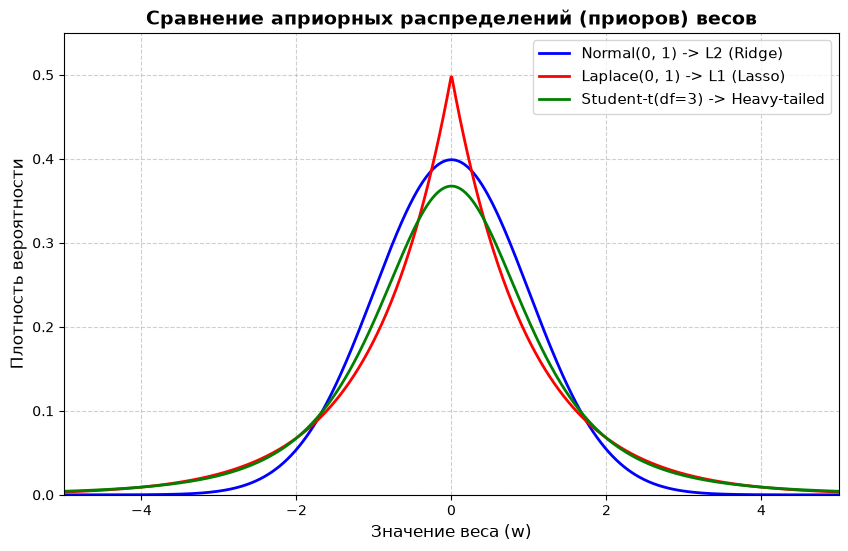

In [ ]:

import matplotlib.pyplot as plt
import scipy.stats as stats

# Задаем диапазон значений для оси X
x = np.linspace(-5, 5, 1000)

# Вычисляем плотности распределений (PDF)
y_normal = stats.norm.pdf(x, loc=0, scale=1)
y_laplace = stats.laplace.pdf(x, loc=0, scale=1)
y_student = stats.t.pdf(x, df=3)

plt.figure(figsize=(10, 6))

plt.plot(x, y_normal, label='Normal(0, 1) -> L2 (Ridge)', color='blue', linewidth=2)
plt.plot(x, y_laplace, label='Laplace(0, 1) -> L1 (Lasso)', color='red', linewidth=2)
plt.plot(x, y_student, label='Student-t(df=3) -> Heavy-tailed', color='green', linewidth=2)

plt.title('Сравнение априорных распределений весов', fontsize=14, fontweight='bold')
plt.xlabel('Значение веса (w)', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.xlim(-5, 5)
plt.ylim(0, 0.55)

plt.show()

### Подробный теоретический разбор приоров

В байесовском подходе к машинному обучению мы ищем веса модели $\mathbf{w}$ с помощью **максимизации апостериорной вероятности (Maximum A Posteriori, MAP)**:

$$\arg\max_{\mathbf{w}} \log P(\mathbf{w}|\mathbf{X}, \mathbf{y}) = \arg\max_{\mathbf{w}} \Big( \log P(\mathbf{y}|\mathbf{X}, \mathbf{w}) + \log P(\mathbf{w}) \Big)$$

*   **Первое слагаемое** — это функция правдоподобия (отвечает за ошибку модели на обучающей выборке, например, MSE).
*   **Второе слагаемое** $\log P(\mathbf{w})$ — это логарифм **априорного распределения (приора)**, который математически эквивалентен **регуляризатору** (штрафу) со знаком минус.

---

#### 1. Нормальное распределение $N(0, \sigma^2)$ и $L_2$-регуляризация (Ridge)

*   **Формула плотности (PDF):** 
    $$P(w) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{w^2}{2\sigma^2}\right)$$
*   **Логарифм приора:** 
    $$\log P(w) = -\frac{1}{2\sigma^2} w^2 + \text{const}$$
*   **Связь с регуляризацией:** Если мы переходим к минимизации функции потерь, то максимизация логарифма плотности превращается в минимизацию штрафа $\lambda \sum w_i^2$, где коэффициент регуляризации обратно пропорционален дисперсии приора: $\lambda = \frac{1}{2\sigma^2}$.
*   **Геометрия и поведение:** 
    *   График плотности имеет гладкую, закругленную вершину (купол) в нуле. Малые значения весов в окрестности нуля обладают практически одинаковой априорной вероятностью.
    *   Производная штрафа по весу равна $2\lambda w$. При приближении веса к нулю сила штрафа линейно угасает и стремится к нулю. Поэтому $L_2$ эффективно уменьшает большие веса, предохраняя модель от переобучения, но **не зануляет их полностью**. Веса группируются около нуля, оставаясь малыми вещественными числами.

---

#### 2. Распределение Лапласа $\text{Laplace}(0, b)$ и $L_1$-регуляризация (Lasso)

*   **Формула плотности (PDF):** 
    $$P(w) = \frac{1}{2b} \exp\left(-\frac{|w|}{b}\right)$$
*   **Логарифм приора:** 
    $$\log P(w) = -\frac{1}{b} |w| + \text{const}$$
*   **Связь с регуляризацией:** Максимизация логарифма этого приора эквивалентна минимизации штрафа Лассо: $\lambda \sum |w_i|$, где параметр регуляризации $\lambda = \frac{1}{b}$.
*   **Геометрия и поведение:**
    *   График имеет характерный **острый пик (излом)** в точке $w=0$. Математически это означает, что функция плотности не дифференцируема в нулю.
    *   Производная (субградиент) штрафа равна $\lambda \cdot \text{sign}(w)$. Сила, толкающая вес к нулю, постоянна и **не уменьшается**, даже когда вес уже очень мал ($w \to 0$).
    *   Этот излом заставляет оптимизатор «застревать» ровно в нуле. В результате $L_1$-регуляризация делает вектор весов **разреженным (sparse)**, полностью обнуляя неинформативные признаки. Это свойство используется для автоматического отбора признаков (feature selection).

---

#### 3. Распределение Стьюдента $t(\nu)$ и Heavy-Tailed регуляризация

*   **Формула плотности (PDF):**

$$P(w) = \frac{\Gamma(\frac{\nu+1}{2})}{\sqrt{\nu\pi}\,\Gamma(\frac{\nu}{2})} \left(1 + \frac{w^2}{\nu}\right)^{-\frac{\nu+1}{2}}$$

*(где $\nu$ — число степеней свободы `df`)*

*   **Логарифм приора:**

$$\log P(w) = -\frac{\nu+1}{2} \log\left(1 + \frac{w^2}{\nu}\right) + \text{const}$$
*   **Связь с регуляризацией:** Соответствует нелинейному вогнутому штрафу вида $\lambda \sum \log(1 + \alpha w_i^2)$.
*   **Геометрия и поведение:**
    *   Распределение Стьюдента обладает **тяжелыми хвостами (heavy tails)**. На графике при $|w| > 2$ его плотность убывает значительно медленнее (по степенному закону), чем у нормального или лапласовского распределений, которые убывают экспоненциально быстро.
    *   Производная логарифма плотности (функция влияния штрафа) при увеличении веса начинает **убывать**: $\frac{\partial}{\partial w} \log P(w) \propto -\frac{w}{1 + w^2/\nu} \to 0$ при $w \to \infty$.
    *   **Эффект сжатия:** Этот приор ведет себя дуально. Вблизи нуля он имеет очень высокий пик, что заставляет оптимизатор эффективно занулять/подавлять мелкие шумовые веса (даже сильнее, чем Ridge). Однако, если признак критически важен для предсказания и вес должен быть огромным, штраф за него практически перестает расти. Это позволяет модели **сохранять единичные сверхбольшие веса** без их искусственного занижения.


---
---
### Как ведут себя штрафы при изменении весов $w$

Поведение регуляризатора полностью определяется тем, с какой скоростью растет штрафная функция при увеличении веса $w$ от нуля до бесконечности ($|w| \to \infty$).

---

#### 1. Штраф $L_2$ (Ridge): Функция $f(w) = w^2$
Этот штраф ведет себя как парабола. 
*   **При уменьшении веса (стремлении к $0$):** Чем ближе вес к нулю, тем медленнее уменьшается штраф. В самой окрестности нуля производная (градиент) штрафа практически равна нулю ($\frac{\partial}{\partial w} w^2 = 2w \to 0$). Из-за этого алгоритму «невыгодно» тратить силы на обнуление совсем маленьких весов.
*   **При увеличении веса:** Штраф растет **параболически (очень быстро)**. Если вес увеличивается в 2 раза, штраф увеличивается в 4 раза. 
*   **Итог:** $L_2$ агрессивно подавляет огромные веса, распределяя нагрузку между всеми признаками поровну, но оставляет микроскопические веса жить, никогда не зануляя их полностью.

---

#### 2. Штраф $L_1$ (Lasso): Функция $f(w) = |w|$
Этот штраф ведет себя как прямые линии, сходящиеся углом (буквой V) в нуле.
*   **При уменьшении веса (стремлении к $0$):** Градиент штрафа остается **постоянным** и равен $\pm 1$ независимо от того, равен ли вес $100$ или $0.00001$. Сила, толкающая вес к нулю, не ослабевает. 
*   **При увеличении веса:** Штраф растет **линейно (умеренно)**. Если вес увеличивается в 2 раза, штраф увеличивается ровно в 2 раза.
*   **Итог:** Для $L_1$ большие веса менее болезненны, чем для $L_2$, но зато у нуля штраф продолжает жестко давить на вес. Это заставляет оптимизатор сбрасывать неважные веса строго в ноль, обеспечивая разреженность (sparsity).

---

#### 3. Штраф Стьюдента (Heavy-tailed): Функция $f(w) = \log(1 + w^2)$
Этот штраф имеет вогнутую форму, которая постепенно «выполаживается» (выравнивается).
*   **При уменьшении веса (стремлении к $0$):** Вблизи нуля функция ведет себя почти как $L_2$ и имеет высокий пик, что позволяет эффективно подавлять мелкий шум.
*   **При увеличении веса:** Штраф растет **логарифмически (крайне медленно)**. При очень больших $w$ производная штрафа начинает стремиться к нулю ($\frac{\partial}{\partial w}\log(1+w^2) \to 0$). 
*   **Итог:** Если вес признака стал очень большим, алгоритму становится почти всё равно — штраф за его дальнейший рост почти не увеличивается. Это позволяет модели сохранять единичные огромные веса (сигналы) без искажений, одновременно зануляя всё остальное.


---
---
8. **Bayes vs MLE на маленькой выборке.** Сгенерируйте 5 бросков монетки (вышло, скажем, 4 орла). MLE даст `p̂ = 0.8`. Что даст MAP с приором `Beta(2, 2)`? Что разумнее?



#### Исходные данные:
* Число бросков (испытаний Бернулли): $n = 5$
* Число успехов (орлов): $k = 4$
* Приор для вероятности успеха $p$: $\text{Beta}(\alpha_0, \beta_0) = \text{Beta}(2, 2)$

#### 1. Оценка максимального правдоподобия (MLE)
MLE оценивает вероятность исключительно по частоте в выборке:
$$\hat{p}_{\text{MLE}} = \frac{k}{n} = \frac{4}{5} = 0.8$$

#### 2. Максимизация апостериорной вероятности (MAP)
Для биномиального правдоподобия приор Бета является **сопряженным**. Это значит, что апостериорное распределение тоже будет Бета-распределением, а его параметры просто пересчитываются добавлением успехов и неудач:
$$\alpha_{\text{post}} = \alpha_0 + k = 2 + 4 = 6$$
$$\beta_{\text{post}} = \beta_0 + (n - k) = 2 + (5 - 4) = 3$$

Апостериорное распределение: $P(p|\text{Данные}) = \text{Beta}(6, 3)$.

Оценка MAP — это мода (пик) апостериорного распределения. Для $\text{Beta}(\alpha, \beta)$ мода вычисляется по формуле:
$$\hat{p}_{\text{MAP}} = \frac{\alpha - 1}{\alpha + \beta - 2} = \frac{6 - 1}{6 + 3 - 2} = \frac{5}{7} \approx 0.714$$

*Интуитивный смысл:* Приор $\text{Beta}(2, 2)$ эквивалентен тому, что мы до начала эксперимента *уже видели* 2 воображаемых броска (1 орел и 1 решка). В итоге мы просто объединили воображаемые данные с реальными: $\frac{4 + 1}{5 + 2} = \frac{5}{7}$.

#### Что разумнее?
На малых выборках **разумнее использовать MAP**. 
* **Проблема MLE:** Слишком чувствителен к шуму. При 5 бросках монеты выпадение 4 орлов — обычная флуктуация. MLE слишком агрессивно верит данным. Если бы выпало 5 орлов, MLE дал бы $\hat{p} = 1.0$, полностью исключив возможность выпадения решки в будущем.
* **Преимущество MAP:** Приор $\text{Beta}(2, 2)$ — это «мягкое» предположение о том, что монетка скорее всего честная (пик распределения Бета(2,2) находится в 0.5). Приор удерживает оценку от экстремальных значений (0.8 сдвигается к более разумному 0.714), выполняя роль регуляризатора. При увеличении числа бросков влияние приора угаснет, и MAP сойдется к MLE.


0.8 0.7142857142857143


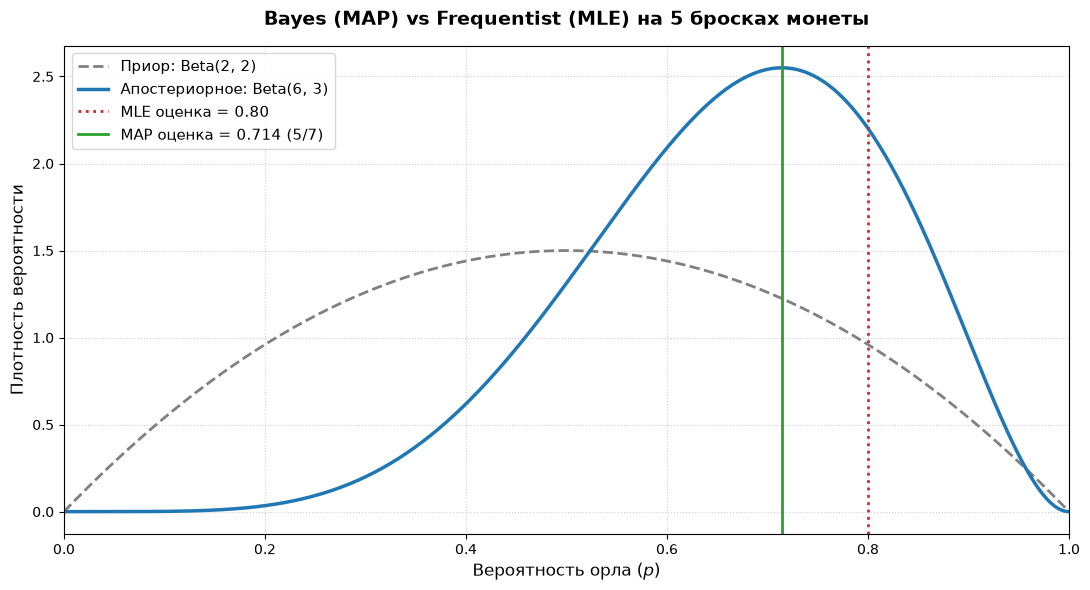

In [37]:
n = 5
k = 4
alpha_prior, beta_prior = 2, 2
alpha_post = alpha_prior + k
beta_post = beta_prior + (n - k)

p_mle = k / n
p_map = (alpha_post - 1) / (alpha_post + beta_post - 2)

print(p_mle, p_map)

p_grid = np.linspace(0, 1, 500)
prior_pdf = stats.beta.pdf(p_grid, alpha_prior, beta_prior)
post_pdf = stats.beta.pdf(p_grid, alpha_post, beta_post)


fig, ax = plt.subplots(figsize=(11, 6), dpi=100)

ax.plot(p_grid, prior_pdf, label='Приор: Beta(2, 2)', color='gray', linestyle='--', linewidth=2)
ax.plot(p_grid, post_pdf, label='Апостериорное: Beta(6, 3)', color='#1f77b4', linewidth=2.5)

ax.axvline(p_mle, color='#d62728', linestyle=':', linewidth=2, label=f'MLE оценка = {p_mle:.2f}')
ax.axvline(p_map, color='#2ca02c', linestyle='-', linewidth=2, label=f'MAP оценка = {p_map:.3f} (5/7)')

ax.set_title('Bayes (MAP) vs Frequentist (MLE) на 5 бросках монеты', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Вероятность орла ($p$)', fontsize=12)
ax.set_ylabel('Плотность вероятности', fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(0, 1)
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

---
# Фундаментальная связь машинного обучения и байесовского вывода

В машинном обучении обучение большинства моделей (линейная регрессия, логистическая регрессия, нейросети) строится на минимизации функций потерь (Loss функций). Однако за каждой стандартной функцией потерь и за каждым регуляризатором скрывается строгий вероятностный фундамент: **Метод максимального правдоподобия (MLE)** и **Метод максимизации апостериорной вероятности (MAP)**.

---

## 1. Вывод оценок максимального правдоподобия (MLE)

Метод максимального правдоподобия (Maximum Likelihood Estimation) находит параметры распределения $\theta$, при которых наблюдаемая выборка $X = \{x_1, x_2, \dots, x_n\}$ является наиболее вероятной. 
Так как объекты независимы и одинаково распределены (i.i.d.), их совместная плотность перемножается. Для удобства оптимизации оптимизируют логарифм правдоподобия ($\mathcal{L}(\theta)$):

$$\hat{\theta}_{\text{MLE}} = \arg\max_{\theta} \prod_{i=1}^n P(x_i | \theta) = \arg\max_{\theta} \sum_{i=1}^n \log P(x_i | \theta)$$

Для поиска точки максимума берется производная по параметру $\theta$, приравнивается к нулю и выражается искомый параметр.

### А. Бернуллиевское распределение (Монетка)
Моделирует бинарные события (0 или 1), где вероятность успеха равна $p$.
* **Плотность (PMF):** $P(x) = p^x (1 - p)^{1-x}$
* **Логарифм правдоподобия:** 
  $$\mathcal{L}(p) = \sum_{i=1}^n \log \left( p^{x_i} (1 - p)^{1-x_i} \right) = \sum_{i=1}^n \left( x_i \log p + (1 - x_i) \log(1 - p) \right)$$
  $$\mathcal{L}(p) = \log p \sum_{i=1}^n x_i + \log(1 - p) \left( n - \sum_{i=1}^n x_i \right)$$
* **Поиск максимума:** Обозначим число успехов как $k = \sum x_i$. Берем производную по $p$:
  $$\frac{\partial \mathcal{L}}{\partial p} = \frac{k}{p} - \frac{n - k}{1 - p} = 0 \implies \frac{k}{p} = \frac{n - k}{1 - p} \implies k(1 - p) = p(n - k)$$
  $$k - kp = np - kp \implies \hat{p}_{\text{MLE}} = \frac{k}{n}$$
* **Вывод:** Оценка MLE вероятности бинарного события равна **выборочному среднему** (доле успехов).

### Б. Распределение Пуассона (Счетчик событий)
Моделирует количество событий за фиксированный интервал времени с интенсивностью $\lambda$.
* **Плотность (PMF):** $P(x) = \frac{\lambda^x e^{-\lambda}}{x!}$
* **Логарифм правдоподобия:**
  $$\mathcal{L}(\lambda) = \sum_{i=1}^n \log \left( \frac{\lambda^{x_i} e^{-\lambda}}{x_i!} \right) = \sum_{i=1}^n \left( x_i \log \lambda - \lambda - \log(x_i!) \right) = \log \lambda \sum_{i=1}^n x_i - n\lambda - \sum_{i=1}^n \log(x_i!)$$
* **Поиск максимума:** Берем производную по $\lambda$ (слагаемое с факториалом исчезает, так как не зависит от $\lambda$):
  $$\frac{\partial \mathcal{L}}{\partial \lambda} = \frac{1}{\lambda} \sum_{i=1}^n x_i - n = 0 \implies \frac{1}{\lambda} \sum_{i=1}^n x_i = n \implies \hat{\lambda}_{\text{MLE}} = \frac{1}{n} \sum_{i=1}^n x_i$$
* **Вывод:** Оценка MLE для интенсивности Пуассона равна **среднему арифметическому** значению выборки.

### В. Нормальное (Гауссовское) распределение
Моделирует непрерывную величину с матожиданием $\mu$ и дисперсией $\sigma^2$. Выведем оценку для $\mu$.
* **Плотность (PDF):** $P(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp \left( -\frac{(x - \mu)^2}{2\sigma^2} \right)$
* **Логарифм правдоподобия:**
  $$\mathcal{L}(\mu, \sigma^2) = \sum_{i=1}^n \log \left( \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x_i - \mu)^2}{2\sigma^2}} \right) = - \frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2$$
* **Поиск максимума по $\mu$:** Константа перед суммой исчезает. Берем производную по $\mu$:
  $$\frac{\partial \mathcal{L}}{\partial \mu} = -\frac{1}{2\sigma^2} \sum_{i=1}^n 2(x_i - \mu) \cdot (-1) = \frac{1}{\sigma^2} \sum_{i=1}^n (x_i - \mu) = 0$$
  $$\sum_{i=1}^n x_i - n\mu = 0 \implies \hat{\mu}_{\text{MLE}} = \frac{1}{n} \sum_{i=1}^n x_i$$
* **Вывод:** Оценка математического ожидания нормального распределения также равна **выборочному среднему**.

---

## 2. Вероятностный смысл стандартных Loss-функций

Каждая стандартная функция потерь в машинном обучении в точности соответствует максимизации логарифма правдоподобия при определенном предположении о распределении целевой переменной (таргета).

### Почему MSE $\rightarrow$ это предположение о Гауссовском шуме
Рассмотрим задачу регрессии. Пусть истинная зависимость описывается моделью $f(x, w)$, но наши измерения содержат случайный шум $\epsilon$:
$$y_i = f(x_i, w) + \epsilon_i$$
Если мы предполагаем, что шум распределен **нормально** с нулевым средним $\epsilon \sim N(0, \sigma^2)$, то таргет $y_i$ тоже распределен нормально вокруг предсказания модели: $y_i \sim N(f(x_i, w), \sigma^2)$.

Запишем логарифм правдоподобия для весов $w$:
$$\mathcal{L}(w) = - \frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (y_i - f(x_i, w))^2$$
Чтобы максимизировать это выражение по весам $w$, нам нужно минимизировать вычитаемую сумму. Перейдем от максимизации к минимизации (умножив на $-1$) и уберем константы:
$$\arg\max_w \mathcal{L}(w) = \arg\min_w \sum_{i=1}^n (y_i - f(x_i, w))^2 \equiv \text{MSE}$$
**Вывод:** Минимизация Mean Squared Error (MSE) математически эквивалентна поиску весов методом MLE в предположении, что ошибки модели имеют нормальное распределение.

### Почему Cross-Entropy $\rightarrow$ это предположение о Категориальном распределении
Рассмотрим классификацию на $K$ классов. Модель выдает вектор вероятностей для каждого класса $\hat{y}_{ik} = P(y_i = k | x_i)$. Истинный таргет закодирован с помощью One-Hot Encoding: $y_{ik} = 1$, если объект принадлежит классу $k$, и $0$ в противном случае.

Распределение объектов по классам подчиняется **категориальному (мультиномиальному)** закону.
* **Плотность (PMF) одного объекта:** $P(y_i | x_i, w) = \prod_{k=1}^K \hat{y}_{ik}^{y_{ik}}$
* **Логарифм правдоподобия выборки:**
  $$\mathcal{L}(w) = \sum_{i=1}^n \log \left( \prod_{k=1}^K \hat{y}_{ik}^{y_{ik}} \right) = \sum_{i=1}^n \sum_{k=1}^K y_{ik} \log \hat{y}_{ik}$$
* **Переход к Loss-функции:** Умножаем на $-1$, чтобы инвертировать задачу в минимизацию:
  $$\text{Loss} = - \sum_{i=1}^n \sum_{k=1}^K y_{ik} \log \hat{y}_{ik} \equiv \text{Categorical Cross-Entropy}$$
**Вывод:** Кросс-энтропия — это просто взятый со знаком минус логарифм правдоподобия категориального распределения (или распределения Бернулли, если классов всего два).

---

## 3. Связь регуляризации с Байесовским рассуждением (MAP)

В классическом подходе (MLE) мы ищем только веса, лучше всего описывающие данные. В байесовском подходе мы максимизируем **апостериорную вероятность** весов (Теорема Байеса):
$$P(w | X, y) = \frac{P(y | X, w) \cdot P(w)}{P(X, y)} \implies \arg\max_w \Big( \log P(y | X, w) + \log P(w) \Big)$$

Переходя к минимизации функции потерь (умножение на $-1$), мы получаем:
$$\text{Итоговый Loss} = \underbrace{-\log P(y | X, w)}_{\text{Стандартная ошибка (MSE / CE)}} + \underbrace{\Big( -\log P(w) \Big)}_{\text{ШТРАФ (Регуляризатор)}}$$

То, какое **априорное распределение (приор)** $P(w)$ мы закладываем в модель до начала обучения, полностью определяет математический вид регуляризатора.

### А. L₂-регуляризация (Ridge) = Гауссовский приор
Если мы заранее считаем, что веса распределены по нормальному закону $w_j \sim N(0, \sigma^2)$, их плотность равна $P(w_j) \propto e^{-\frac{w_j^2}{2\sigma^2}}$.
* **Вывод штрафа:** $-\log P(w_j) = \frac{1}{2\sigma^2} w_j^2 + \text{const} \implies \lambda w_j^2$
* **Геометрия:** График плотности — гладкий купол. Производная штрафа ($2\lambda w$) линейно затухает у нуля. Штраф агрессивно подавляет огромные веса, но оставляет мелкие веса жить, никогда не зануляя их полностью.

### Б. L₁-регуляризация (Lasso) = Лапласовский приор
Если мы закладываем распределение Лапласа $w_j \sim \text{Laplace}(0, b)$, плотность равна $P(w_j) \propto e^{-\frac{|w_j|}{b}}$.
* **Вывод штрафа:** $-\log P(w_j) = \frac{1}{b} |w_j| + \text{const} \implies \lambda |w_j|$
* **Геометрия:** График имеет острый излом (шпиль) в нуле. Производная штрафа ($\lambda \cdot \text{sign}(w)$) постоянна. Сила, толкающая вес к нулю, не ослабевает, даже если вес микроскопический. Это заставляет оптимизатор «застревать» ровно в нуле, создавая **разреженные векторы весов** (автоматический отбор признаков).

---

## 4. Применение MAP vs MLE на маленькой выборке (Практический пример)

На маленьких выборках метод MLE часто страдает от сильного переобучения под случайный шум. Использование MAP с адекватным приором позволяет сгладить оценку.

### Задача:
Мы подбросили монетку $n = 5$ раз. Выпало $k = 4$ орла. Нам нужно оценить истинную вероятность выпадения орла $p$.

#### 1. Решение через MLE (Частотный подход)
Как было выведено в пункте 1А, MLE смотрит только на данные:
$$\hat{p}_{\text{MLE}} = \frac{k}{n} = \frac{4}{5} = 0.8$$

#### 2. Решение через MAP (Байесовский подход)
Зададим априорное предположение, что монетка скорее всего честная. Для этого отлично подходит сопряженное Бета-распределение: приор $P(p) = \text{Beta}(2, 2)$. Его пик находится ровно в $0.5$.

Благодаря свойству сопряженности, апостериорное распределение тоже будет Бета-распределением, параметры которого пересчитываются тривиальным добавлением успехов и неудач:
$$\alpha_{\text{post}} = \alpha_{\text{prior}} + k = 2 + 4 = 6$$
$$\beta_{\text{post}} = \beta_{\text{prior}} + (n - k) = 2 + (5 - 4) = 3$$
Получили $P(p | \text{Данные}) = \text{Beta}(6, 3)$.

Оценка MAP — это точка максимума (мода) получившегося распределения. Для $\text{Beta}(\alpha, \beta)$ она вычисляется по формуле:
$$\hat{p}_{\text{MAP}} = \frac{\alpha - 1}{\alpha + \beta - 2} = \frac{6 - 1}{6 + 3 - 2} = \frac{5}{7} \approx 0.714$$

*Интуиция регуляризации:* Приор $\text{Beta}(2, 2)$ эквивалентен тому, что мы до начала эксперимента *уже видели* 2 виртуальных броска (1 орел и 1 решка). Оценка MAP просто объединила наш прошлый опыт и новые данные: $\frac{4 + 1}{5 + 2} = \frac{5}{7}$.

### Что разумнее?
В данном случае **гораздо разумнее использовать MAP**. 
* Оценка MLE ($0.8$) слишком радикальна для пяти бросков — обычная случайность заставила модель поверить, что монетка сильно скошена. Если бы нам выпало 5 орлов из 5, MLE выдал бы $\hat{p}=1.0$, категорически утверждая, что решка не выпадет никогда в жизни.
* MAP выступает как регуляризатор. Он удерживает оценку от крайностей, плавно подтягивая её от зашумленного значения $0.8$ ближе к здравому смыслу ($0.714$). По мере роста выборки (например, до 500 бросков) влияние приора исчезнет, и MAP автоматически сойдется к истинному MLE.
